# Generalized E3SMLE and CESM-SMYLE RMSE Comparison Maps

This notebook computes and plots seasonal direct RMSE comparisons for `TREFHT`, `TS`, `PRECT`, or `PSL` using the same workflow and native seasonal-lead conventions as `1b_atm_leadtime_rmse_skill_map.ipynb`. Ocean-realm fields (e.g. `SST`) use the same pipeline but live in the companion notebook `1c_ocn_leadtime_rmse_compare.ipynb`.

Change only the `field` assignment in the configuration cell below:

```python
# field = "TREFHT"  # surface air temperature
# field = "TS"      # all-surface radiative/skin temperature
# field = "PRECT"   # precipitation
# field = "PSL"     # sea-level pressure
```

Variable-specific observation product, observation variable name, unit conversion, labels, color scales, and field-specific cache filenames are derived from `field` and `VAR_CONFIG`.

This workflow supports these comparison sources (enable E3SM cases in the configuration block):

- `WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce`
- `WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL`
- `WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn`
- `CESM-SMYLE`

Set `reference_model` (default `"CESM-SMYLE"`; auto-switches to `E3SM_REFERENCE_CASE` when `VAR_CONFIG[field]["has_smyle_benchmark"]` is `False`) to compare every other enabled E3SM case directly against any single reference — CESM-SMYLE or an E3SM case — with the same bootstrap significance testing either way.

The evaluation period, excluded year, and initialization months are configured under `WORKFLOW_SETTINGS["run"]`; `YEAR_END` provides the optional common end-year shortcut used by the enabled cases.

This notebook uses direct model-vs-observation RMSE and matched-ensemble resampling to compare the configured hindcasts with CESM-SMYLE. Enabled E3SM cases are required to provide complete-member postprocessed inputs across the configured evaluation period; otherwise adjust the period or disable the case in the configuration block. Comparisons use the verification years common to the enabled hindcast and CESM-SMYLE.

For a fresh or source-validating run, keep `cache.source_identity_mode="inventory"`
and `prepared_inputs.mode="auto"`. After that run creates every prepared direct-RMSE
input, an archive-free restart uses `cache.source_identity_mode="snapshot"` with
`prepared_inputs.mode="require"`; this fails early if any signed inventory snapshot
or prepared input is missing or incompatible.


In [85]:
%load_ext autoreload
%autoreload 2
import os
import sys
from pathlib import Path

# Ensure repository root is on sys.path so top-level packages (like workflows) are importable
_repo_override = os.environ.get("ESP_LAB_REPO_ROOT")
_repo_candidates = (
    [Path(_repo_override).expanduser().resolve()]
    if _repo_override
    else [Path.cwd().resolve(), *Path.cwd().resolve().parents]
)
REPO_ROOT = next((p for p in _repo_candidates if (p / "workflows").is_dir()), None)
if REPO_ROOT and str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
from esp_lab import data_access_e3sm as data_access
from esp_lab import env_paths
from esp_lab import data_access_obs as obs_access
from esp_lab import data_access_cesm_smyle as smyle_access
from esp_lab import stats
from esp_lab.leadtime_skill_cache import (
    file_inventory_digest, generate_member_indices,
    load_or_write_member_selection, member_selection_attrs,
    source_fingerprint, stable_resampling_seed,
)
from esp_lab.leadtime_prepared_cache import cache_status
from esp_lab.leadtime_workflow import resolve_source_revision

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import regrid_utils as regrid
from esp_lab.utils import mov_utils as mov
from esp_lab.utils.filename_utils import figure_filename
from esp_lab.utils.netcdf_utils import atomic_to_netcdf, load_netcdf
from esp_lab.utils.resource_utils import ResourceTracker
from workflows.leadtime_skill import rmse_comparison as rmse_compare_helper

from esp_lab.utils.dask_util import DaskConfig, get_cluster_client, close_cluster


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Preprocessing:  Data I/O using Dask

### Create Dask Cluster

In [86]:
import dask
from dask.distributed import (
    wait,
    get_client
)

from esp_lab.utils.notebook_resources import restart_notebook_cluster, close_notebook_resources

machine_env = os.environ.get('CLUSTER_TYPE', 'local')
# Four 4-GB workers fit the shared-login safety cap and avoid a misleading
# 30-worker request that the cluster helper would silently reduce.
dask_workers = 4

dask_cfg = DaskConfig(
    cluster_type=machine_env, workers=dask_workers, memory_limit="4GB"
)
cluster, client, workflow_resources = restart_notebook_cluster(
    globals(), lambda: get_cluster_client(dask_cfg)
)

dask.__version__

cluster


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
This can easily exceed memory/CPU limits and crash your Jupyter kernel.
We highly recommend launching Jupyter on an Exclusive Perlmutter Compute Node.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
Scheduler: tcp://127.0.0.1:42457
Connected workers: 4
Dashboard: http://127.0.0.1:41279/status


LocalCluster(fdbfebec, 'tcp://127.0.0.1:42457', workers=4, threads=4, memory=14.90 GiB)

### Read in EAM monthly data; Convert to Seasonal averages (DJF, MAM, JJA, SON)
- Chosen field is returned as a dask array with leading dimensions of Y (initialization year), M (ensemble member), and L (lead season). For example, for November starts, L=1 corresponds to first DJF season.
- "time" which gives prediction verification time (centered time for a given season) is also dimensioned with (Y,L)

In [87]:
%%time
# -----------------------------------------------------------------------------
# Variable-driven setup + period-based multi-case E3SM setup
# -----------------------------------------------------------------------------
# Change this one line to switch diagnostics:
#   field = "TREFHT"  -> ERA5 tas, model/obs K -> degC
#   field = "PRECT"   -> GPCP PRECT, model m/s -> mm/day
#   field = "PSL"     -> ERA5 psl, model/obs Pa -> hPa
#   filed = "TS"     -> ERA5 ts, model/obs K -> degC

#field = "TREFHT"
#field = "PRECT"
#field = "TS"
field = "PSL"

# mode for derivation of variables choices (prepared RMSE inputs):
# "auto": automatically determine whether to rebuild or use cached results
# "rebuild": force recomputation
# "require": require cached results and fail if not available
derivation_mode = "auto"

# True to force recomputation of direct RMSE metrics, False (default) to use cached results if available
recompute_rmse = False

# True to force recomputation of bootstrap comparison metrics, False (default) to use cached results if available
recompute_compare = False

# Optional common processing end year. None uses the end year from
# run.initialization_years.
YEAR_END = 2011  # None

case_nens = 10
case_nlead = 24
smyle_nens = 20
smyle_nlead = 24

# Central controls mirror the finalized 1a workflow and are consumed by all stages.
WORKFLOW_SETTINGS = {
    'paths': {'e3sm_data_dir': str(env_paths.raw_model_root())},
    'run': {'smoke_mode': False, 'initialization_years': (1980, 2018 if YEAR_END is None else int(YEAR_END)),
            'year_end': YEAR_END, 'years': (1980, 2018 if YEAR_END is None else int(YEAR_END)),
            'exclude_year': None,
            'init_months': [5, 11], 'climatology_years': (1981, 2010)},
    'regrid': {
        'target_dlat': 5.0,
        'target_dlon': 5.0,
        'method': 'conservative',
        'periodic': True,
    },
    'cache': {'source_identity_mode': 'inventory', 'force_rewrite_inputs': False,
              'force_compute_direct_rmse': recompute_rmse, 'force_compute_comparison': recompute_compare,
              'cleanup_temp_files': True, 'temp_file_max_age_hours': 24.0},
    'prepared_inputs': {'mode': derivation_mode, 'force_recompute': recompute_rmse},
    'significance': {'iterations': 100, 'random_seed': 42, 'alpha': 0.1},
}
if WORKFLOW_SETTINGS['run']['smoke_mode']:
    # initialization_years/year_end drive PROCESSING_YEARS, so reset them too.
    WORKFLOW_SETTINGS['run'].update(initialization_years=(1980, 1984), year_end=None,
                                    years=(1980, 1984), init_months=[11],
                                    climatology_years=(1980, 1984))
    WORKFLOW_SETTINGS['significance']['iterations'] = 3
    WORKFLOW_SETTINGS['regrid'].update(target_dlat=5.0, target_dlon=5.0)

# =============================================================================
# USER-CONTROLLED WORKFLOW CONFIGURATION
# =============================================================================
S2D_DIAG_ROOT = env_paths.s2d_diag_root()
SMYLE_BENCHMARK_DIR = S2D_DIAG_ROOT / "CESM-SMYLE"
FIGURE_OUTDIR = env_paths.figure_root()
OBS_DATA_DIR = Path(str(env_paths.obs_root()))
DATA_DIR_CANDIDATES = [
    str(env_paths.raw_model_root()),
    "/global/cfs/cdirs/e3smdata/simulations/S2S2D/post_process",
]

# Toggle cases here instead of commenting dictionary entries throughout the notebook.
E3SM_CASE_CATALOG = {
    "E3SM-Reanalysis": {
        "enabled": True,
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_BruteForce",
        "cache_tag": "Reanalysis",
        "display_name": "E3SMv3-Reanalysis",
        "source_revision": "post_process_v1",
    },
    "E3SM-FOSIRL": {
        "enabled": True,
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL",
        "cache_tag": "JRA55_FOSIRL",
        "display_name": "E3SMv3-FOSIRL",
        "source_revision": "post_process_v1",
    },
    "E3SM-4DEnVarOcn": {
        "enabled": True,
        "case_prefix": "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_4DEnVarOcn",
        "cache_tag": "4DEnVarOcn",
        "display_name": "E3SMv3-4DEnVarOcn",
        "source_revision": "post_process_v1",
    },
}
E3SM_REFERENCE_CASE = "E3SM-FOSIRL"

RUN = WORKFLOW_SETTINGS['run']
run_year_start, run_year_end = map(int, RUN.get('initialization_years', RUN['years']))
configured_year_end = RUN.get('year_end')
effective_year_end = run_year_end if configured_year_end is None else int(configured_year_end)
years, yeare = run_year_start, effective_year_end
yexcl = WORKFLOW_SETTINGS['run']['exclude_year']
init_months = list(WORKFLOW_SETTINGS['run']['init_months'])
climy0, climy1 = WORKFLOW_SETTINGS['run']['climatology_years']

target_dlat = WORKFLOW_SETTINGS['regrid']['target_dlat']
target_dlon = WORKFLOW_SETTINGS['regrid']['target_dlon']
regrid_method = WORKFLOW_SETTINGS['regrid']['method']
regrid_periodic = WORKFLOW_SETTINGS['regrid']['periodic']
target_grid_identity = f"latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}"
destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)

REQUIRE_COMPLETE_EVALUATION_PERIOD = True
FORCE_REWRITE_SEASONAL_CACHE = WORKFLOW_SETTINGS['cache']['force_rewrite_inputs']
FORCE_COMPUTE_DIRECT_RMSE = WORKFLOW_SETTINGS['cache']['force_compute_direct_rmse']
N_RESAMPLES = WORKFLOW_SETTINGS['significance']['iterations']
BOOT_RANDOM_SEED = WORKFLOW_SETTINGS['significance']['random_seed']
BOOT_ALPHA = WORKFLOW_SETTINGS['significance']['alpha']
FORCE_COMPUTE_BOOTSTRAP = WORKFLOW_SETTINGS['cache']['force_compute_comparison']
BOOT_LEADS = None

# Analysis-specific metadata lives in the notebook, not in rmse_compare_helper.
# Each field reads its observations from obs_path_pattern: an explicit file path
# or glob (e.g. one file per year), loaded by
# obs_access.get_monthly_data_from_pattern.
VAR_CONFIG = {
    "TREFHT": {
        "long_name": "2-m air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "tas",
        "obs_path_pattern": f"{env_paths.obs_root()}/ERA5/tas_*.nc",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "smyle_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "obs_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
        "has_smyle_benchmark": True,
    },
    "TS": {
        "long_name": "surface air temperature",
        "plot_name": "Surface air temperature",
        "obs_name": "ERA5",
        "obs_var": "ts",
        "obs_path_pattern": f"{env_paths.obs_root()}/ERA5/ts_*.nc",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "smyle_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "obs_convert": rmse_compare_helper.convert_kelvin_to_celsius,
        "units": r"$^\circ$C",
        "has_smyle_benchmark": True,
    },
    "PRECT": {
        "long_name": "precipitation",
        "plot_name": "Precipitation",
        "obs_name": "GPCP_v2.3",
        "obs_var": "PRECT",
        "obs_path_pattern": f"{env_paths.obs_root()}/GPCP_v2.3/PRECT_*.nc",
        "obs_ys": "1979",
        "obs_ye": "2017",
        "model_convert": rmse_compare_helper.convert_precip_mps_to_mmday,
        "smyle_convert": rmse_compare_helper.convert_precip_mps_to_mmday,
        "obs_convert": lambda da: rmse_compare_helper.no_unit_conversion(da, units="mm/day"),
        "units": "mm/day",
        "has_smyle_benchmark": True,
    },
    "PSL": {
        "long_name": "sea-level pressure",
        "plot_name": "Sea-level pressure",
        "obs_name": "ERA5",
        "obs_var": "psl",
        "obs_path_pattern": f"{env_paths.obs_root()}/ERA5/psl_*.nc",
        "obs_ys": "1979",
        "obs_ye": "2019",
        "model_convert": rmse_compare_helper.convert_pa_to_hpa,
        "smyle_convert": rmse_compare_helper.convert_pa_to_hpa,
        "obs_convert": rmse_compare_helper.convert_pa_to_hpa,
        "units": "hPa",
        "has_smyle_benchmark": True,
    },
}

if field not in VAR_CONFIG:
    raise ValueError(f"Unsupported field={field!r}. Available fields: {list(VAR_CONFIG)}")

cfg = VAR_CONFIG[field]
analysis_component = cfg.get('component', 'atm')
e3sm_field = cfg.get('e3sm_field', field)
smyle_field = cfg.get('smyle_field', field)

# The model compared against every E3SM case. Defaults to CESM-SMYLE when
# available; set explicitly to an enabled E3SM case (e.g. E3SM_REFERENCE_CASE)
# to compare cases directly when no CESM-SMYLE benchmark exists for this field.
reference_model = "CESM-SMYLE" if cfg.get("has_smyle_benchmark", True) else E3SM_REFERENCE_CASE
if reference_model == "CESM-SMYLE" and not cfg.get("has_smyle_benchmark", True):
    raise ValueError(
        f"reference_model=\"CESM-SMYLE\" but field={field!r} has no CESM-SMYLE "
        "benchmark (has_smyle_benchmark=False); set reference_model to an "
        "enabled E3SM case instead."
    )

# Field-specific map colorbar configuration.
# `levels` control color boundaries; `ticks` control displayed labels.
MAP_COLORBAR_CONFIG = {
    "absolute_rmse": {
        "TREFHT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                   "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "TS": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                   "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PRECT": {"levels": [0, 0.5, 1, 1.5, 2, 2.5, 3],
                  "ticks": [0, 0.5, 1, 1.5, 2, 2.5, 3], "decimals": 1},
        "PSL": {"levels": [0, 2, 4, 6, 8, 10, 12],
                "ticks": [0, 2, 4, 6, 8, 10, 12], "decimals": 1},
    },
    "rmse_difference": {
        "TREFHT": {
            "levels": [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5,
                       0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4],
            "ticks": [-4, -3, -2, -1, 0, 1, 2, 3, 4], "decimals": 1,
        },
        "TS": {
            "levels": [-4, -3.5, -3, -2.5, -2, -1.5, -1, -0.5,
                       0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4],
            "ticks": [-4, -3, -2, -1, 0, 1, 2, 3, 4], "decimals": 1,
        },
        "PRECT": {
            "levels": [-3, -2.5, -2, -1.5, -1, -0.5, 0,
                       0.5, 1, 1.5, 2, 2.5, 3],
            "ticks": [-3, -2, -1, 0, 1, 2, 3], "decimals": 1,
        },
        "PSL": {
            "levels": [-12, -10, -8, -6, -4, -2, 0,
                       2, 4, 6, 8, 10, 12],
            "ticks": [-12, -8, -4, 0, 4, 8, 12], "decimals": 1,
        },
    },
}

compact_year_tag = rmse_compare_helper.compact_year_tag

print(f"Selected field: {field} ({cfg['long_name']})")
print(f"Observation product: {cfg['obs_name']} variable={cfg['obs_var']}")

data_dir = WORKFLOW_SETTINGS['paths']['e3sm_data_dir']
if not data_dir:
    raise ValueError('Set paths.e3sm_data_dir explicitly.')
print(f"Using configured post-processed data directory: {data_dir}")

E3SM_CASES = {
    case_key: {key: value for key, value in case_info.items() if key != "enabled"}
    for case_key, case_info in E3SM_CASE_CATALOG.items()
    if case_info.get("enabled", False)
}
if not E3SM_CASES:
    raise ValueError("Enable at least one entry in E3SM_CASE_CATALOG.")
if E3SM_REFERENCE_CASE not in E3SM_CASES:
    raise ValueError(
        f"E3SM_REFERENCE_CASE={E3SM_REFERENCE_CASE!r} must be enabled; "
        f"enabled cases are {list(E3SM_CASES)}"
    )
if reference_model != "CESM-SMYLE" and reference_model not in E3SM_CASES:
    raise ValueError(
        f"reference_model={reference_model!r} must be \"CESM-SMYLE\" or an "
        f"enabled E3SM case; enabled cases are {list(E3SM_CASES)}"
    )
reference_nens = smyle_nens if reference_model == "CESM-SMYLE" else case_nens
# Every other enabled E3SM case compared directly against reference_model.
REQUESTED_DIFFERENCE_COMPARISONS = [
    (case_key, reference_model) for case_key in E3SM_CASES
    if case_key != reference_model
]
MODEL_DIAG_ROOTS = {
    "CESM-SMYLE": S2D_DIAG_ROOT / "CESM-SMYLE",
    **{
        case_key: S2D_DIAG_ROOT / case_info["cache_tag"]
        for case_key, case_info in E3SM_CASES.items()
    },
}
PERIOD_COMPARE_CACHE_ROOTS = {
    case_key: MODEL_DIAG_ROOTS[case_key] / "leadtime_acc" / "work" / analysis_component / "period_compare"
    for case_key in E3SM_CASES
}
DIRECT_RMSE_ROOTS = {
    model: root / "leadtime_acc" / "comparison" / analysis_component / "direct_rmse"
    for model, root in MODEL_DIAG_ROOTS.items()
}

FIGURE_OUTDIR.mkdir(parents=True, exist_ok=True)

# Stable output names: rerunning a field replaces its previous figures.
FIGURE_FILENAMES = {
    "compare_global": f"fig_rmse_compare_{field.lower()}_rmse_compare_global.png",
    "compare_conus": f"fig_rmse_compare_{field.lower()}_rmse_compare_conus.png",
    "difference_compare": f"fig_rmse_compare_{field.lower()}_rmse_difference_compare.png",
    "difference_compare_by_init": {
        m: f"fig_rmse_compare_{field.lower()}_rmse_difference_compare_init{m:02d}.png"
        for m in init_months
    },
}

if years > yeare:
    raise ValueError(f"years ({years}) must be <= yeare ({yeare}).")
if "E3SM-4DEnVarOcn" in E3SM_CASES and yeare > 2011:
    raise ValueError(
        f"E3SM-4DEnVarOcn only spans 1980-2011. For multi-model comparison with 4DEnVar, "
        f"set YEAR_END = 2011 or remove 'E3SM-4DEnVarOcn' from E3SM_CASES."
    )
if not init_months or any(month < 1 or month > 12 for month in init_months):
    raise ValueError(f"init_months must contain calendar months 1-12: {init_months}")

lead_years = [year for year in np.arange(years, yeare + 1) if year != yexcl]
INIT_YEARS_BY_MONTH = {init_month: lead_years for init_month in init_months}

# Provenance identities are resolved before any cache decision. Inventory mode
# records the exact archive inventory; snapshot mode reuses that signed record.
source_identity_mode = WORKFLOW_SETTINGS['cache']['source_identity_mode']
prepared_input_mode = WORKFLOW_SETTINGS['prepared_inputs']['mode']
prepared_input_force = WORKFLOW_SETTINGS['prepared_inputs']['force_recompute']
if source_identity_mode not in {'inventory', 'snapshot', 'revision'}:
    raise ValueError("cache.source_identity_mode must be inventory, snapshot, or revision")
if prepared_input_mode not in {'auto', 'rebuild', 'require'}:
    raise ValueError("prepared_inputs.mode must be auto, rebuild, or require")
if source_identity_mode == 'snapshot' and prepared_input_mode != 'require':
    raise ValueError("Snapshot mode requires prepared_inputs.mode='require'")
if prepared_input_mode == 'require' and prepared_input_force:
    raise ValueError("prepared_inputs.force_recompute cannot be used with mode='require'")

snapshot_dir = S2D_DIAG_ROOT / 'tmp' / 'source_inventory_snapshots'
if not snapshot_dir.exists() and (S2D_DIAG_ROOT / 'source_inventory_snapshots').exists():
    snapshot_dir = S2D_DIAG_ROOT / 'source_inventory_snapshots'
def resolved_revision(configured_revision, paths, root, identity):
    return resolve_source_revision(
        source_identity_mode, configured_revision, identity=identity,
        snapshot_dir=snapshot_dir, paths=paths, root=root)

e3sm_source_identity_by_case_month = {}
for case_key, case_info in E3SM_CASES.items():
    e3sm_source_identity_by_case_month[case_key] = {}
    for init_month in init_months:
        identity = {
            'archive_root': str(data_dir), 'case_prefix': case_info['case_prefix'],
            'field': e3sm_field, 'init_month': init_month,
            'requested_years': [int(y) for y in INIT_YEARS_BY_MONTH[init_month]],
            'members': [f'EN{i:02d}' for i in range(case_nens)],
            'lead_count': case_nlead, 'frequency': 'monthly',
        }
        source_files = []
        if source_identity_mode == 'inventory':
            tags = data_access.build_init_tags(INIT_YEARS_BY_MONTH[init_month], init_month)
            nested, valid_tags = data_access.nested_file_list_by_init(
                data_dir=data_dir, case_prefix=case_info['case_prefix'],
                members=identity['members'], init_tags=tags, field=e3sm_field,
                realm=cfg.get('e3sm_realm', 'atm'), grid='180x360_aave', freq='monthly', ts_split='2yr',
                require_all_members=True, verify_field_name=True,
                verify_coverage=True, nlead=case_nlead)
            if valid_tags != tags:
                raise FileNotFoundError(
                    f'Incomplete inventory for {case_key}, month {init_month:02d}')
            source_files = [path for group in nested for path in group]
        revision = resolved_revision(
            case_info['source_revision'], source_files, data_dir, identity)
        e3sm_source_identity_by_case_month[case_key][init_month] = source_fingerprint(
            identity, source_revision=revision)

if cfg.get("has_smyle_benchmark", True):
    smyle_source_identity_by_month = {}
    for init_month in init_months:
        identity = {
            'benchmark_root': str(SMYLE_BENCHMARK_DIR), 'field': smyle_field,
            'init_month': init_month, 'ensemble_member_count': smyle_nens,
            'lead_count': smyle_nlead, 'frequency': 'seas',
            'requested_years': [int(y) for y in INIT_YEARS_BY_MONTH[init_month]],
        }
        source_files = []
        if source_identity_mode == 'inventory':
            source_files = [smyle_access.benchmark_path(
                smyle_field, init_month, SMYLE_BENCHMARK_DIR, nens=smyle_nens,
                nlead=smyle_nlead, freq='seas')]
        revision = resolved_revision(
            'benchmark_v1', source_files, SMYLE_BENCHMARK_DIR, identity)
        smyle_source_identity_by_month[init_month] = source_fingerprint(
            identity, source_revision=revision)
else:
    smyle_source_identity_by_month = {}

engine = "netcdf4"
members = [f"EN{i:02d}" for i in range(case_nens)]

require_all_members = True
verify_field_name = True
verify_coverage = True
debug = True

# Optional: safer open-time chunking.
chunks_open = {} # {"L": 24} can be used if needed.

mchunk = {
    "Y": 3,
    "L": 24,
    "M": 2,
    "lat": 90,
    "lon": 180,
}

# ===== END CONFIGURATION BLOCK =====

Selected field: PSL (sea-level pressure)
Observation product: ERA5 variable=psl
Using configured post-processed data directory: /global/cfs/cdirs/e3sm/S2S2D/post_process
CPU times: user 10.7 s, sys: 4.74 s, total: 15.5 s
Wall time: 3min 1s


In [88]:
def e3sm_seasonal_cache_spec(case_key, init_month):
    case_info = E3SM_CASES[case_key]
    cache_tag = case_info['cache_tag']
    year_tag = compact_year_tag(INIT_YEARS_BY_MONTH[init_month])
    path = PERIOD_COMPARE_CACHE_ROOTS[case_key] / field / (
        f'{cache_tag}_init{init_month:02d}_{field}_N{case_nens:02d}_M{case_nlead:02d}_years_{year_tag}_seas.nc')
    attrs = {
        'cache_kind': 'seasonal_e3sm_input_v2', 'source': cache_tag,
        'source_data_identity': e3sm_source_identity_by_case_month[case_key][init_month],
        'case_prefix': case_info['case_prefix'], 'variable': field,
        'initialization_month': int(init_month),
        'requested_years': ','.join(map(str, INIT_YEARS_BY_MONTH[init_month])),
        'ensemble_member_count': int(case_nens), 'lead_count': int(case_nlead),
    }
    return path, attrs

def direct_input_spec(source, init_month, source_identity, ensemble_size):
    years_this = INIT_YEARS_BY_MONTH[init_month]
    expected = {
        'cache_kind': 'prepared_direct_rmse_model_v1', 'source': source,
        'source_data_identity': source_identity, 'variable': field,
        'initialization_month': int(init_month),
        'requested_years': ','.join(map(str, years_this)),
        'ensemble_member_count': int(ensemble_size),
        'lead_count': int(case_nlead // 3),
        'target_grid': f'latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}',
        'regridding_method': regrid_method,
        'unit_conversion_version': 'leadtime_rmse_units_v1',
    }
    fixed_filename = f'{source}_{field}_init{init_month:02d}_years_{compact_year_tag(years_this)}.nc'
    path = S2D_DIAG_ROOT / source / 'leadtime_rmse' / 'inputs' / analysis_component / field / fixed_filename
    return path, expected


e3sm_direct_input_specs = {
    case: {month: direct_input_spec(
        info['cache_tag'], month, e3sm_source_identity_by_case_month[case][month],
        case_nens) for month in init_months}
    for case, info in E3SM_CASES.items()
}

if cfg.get("has_smyle_benchmark", True):
    smyle_direct_input_specs = {
        month: direct_input_spec(
            'CESM-SMYLE', month, smyle_source_identity_by_month[month], smyle_nens)
        for month in init_months
    }
else:
    smyle_direct_input_specs = {}
    
obs_identity = {
    'obs_root': str(OBS_DATA_DIR), 'product': cfg['obs_name'],
    'variable': cfg['obs_var'], 'archive_years': [cfg['obs_ys'], cfg['obs_ye']],
}
obs_source_files = []
if source_identity_mode == 'inventory':
    obs_source_files = obs_access.resolve_glob_files(cfg['obs_path_pattern'])
obs_revision = resolved_revision(
    'obs_archive_v1', obs_source_files, Path(cfg['obs_path_pattern']).parent, obs_identity)
obs_source_identity = source_fingerprint(obs_identity, source_revision=obs_revision)
obs_fixed_filename = f"{cfg['obs_name']}_{field}.nc"

canonical_obs_path = S2D_DIAG_ROOT / 'observations' / 'leadtime_rmse' / 'inputs' / analysis_component / field / obs_fixed_filename
if canonical_obs_path.exists():
    obs_prepared_path = canonical_obs_path
else:
    legacy_obs_filename = f"{cfg['obs_name']}_{obs_source_identity.split(':')[-1]}.nc"
    legacy_canonical_obs = S2D_DIAG_ROOT / 'observations' / 'leadtime_rmse' / 'inputs' / analysis_component / field / legacy_obs_filename
    legacy_prepared_obs = S2D_DIAG_ROOT / 'prepared_direct_rmse_inputs' / analysis_component / field / 'observations' / legacy_obs_filename
    if legacy_canonical_obs.exists():
        obs_prepared_path = legacy_canonical_obs
    elif legacy_prepared_obs.exists():
        obs_prepared_path = legacy_prepared_obs
    else:
        obs_prepared_path = canonical_obs_path
obs_prepared_attrs = {
    'cache_kind': 'prepared_direct_rmse_observations_v1',
    'observation_data_identity': obs_source_identity, 'variable': field,
    'target_grid': f'latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}',
    'regridding_method': regrid_method,
    'unit_conversion_version': 'leadtime_rmse_units_v1',
}
all_direct_specs = [
    spec for by_month in e3sm_direct_input_specs.values()
    for spec in by_month.values()
] + list(smyle_direct_input_specs.values())
missing_direct_inputs = [
    (path, reason) for path, expected in all_direct_specs
    for compatible, reason in [cache_status(
        path, expected_attrs=expected,
        required_variables=('model', 'verification_time'))]
    if not compatible
]
obs_prepared_ok, obs_prepared_reason = cache_status(
    obs_prepared_path, expected_attrs=obs_prepared_attrs,
    required_variables=('observation',))
if not obs_prepared_ok:
    missing_direct_inputs.append((obs_prepared_path, obs_prepared_reason))
if prepared_input_mode == 'require' and missing_direct_inputs:
    details = '\n'.join(f'  - {path}: {reason}' for path, reason in missing_direct_inputs)
    raise RuntimeError(f'Required prepared direct-RMSE inputs are unavailable:\n{details}')
use_prepared_direct_inputs = (
    prepared_input_mode != 'rebuild' and not prepared_input_force
    and not missing_direct_inputs
)

e3sm_months_to_load_raw = {
    case_key: [month for month in init_months if (
        FORCE_REWRITE_SEASONAL_CACHE or not cache_status(
            e3sm_seasonal_cache_spec(case_key, month)[0],
            expected_attrs=e3sm_seasonal_cache_spec(case_key, month)[1],
            required_variables=(field,))[0])]
    for case_key in E3SM_CASES
}
print('Raw E3SM case/month inputs required:', e3sm_months_to_load_raw)

print(f"Evaluation period: {years}-{yeare}; excluded year: {yexcl}")
print(f"Initialization months: {init_months}")
print(f"Initialization years per month: {len(lead_years)}")


if use_prepared_direct_inputs:
    print('All prepared direct-RMSE inputs are valid; skipping raw E3SM archive access.')
else:
    e3sm_raw_by_case_month = {}

    for case_key, case_info in E3SM_CASES.items():
        case_prefix = case_info["case_prefix"]
        e3sm_raw_by_case_month[case_key] = {}

        print("")
        print("=" * 80)
        print(f"Loading {case_key}: {case_prefix}")
    
        for init_month in e3sm_months_to_load_raw[case_key]:
            lead_years = INIT_YEARS_BY_MONTH[init_month]
            init_tags = data_access.build_init_tags(lead_years, init_month)

            e3sm = data_access.get_monthly_data(
                data_dir=data_dir,
                case_prefix=case_prefix,
                members=members,
                init_tags=init_tags,
                field=e3sm_field,
                nlead=case_nlead,
                chunks=chunks_open,
                realm=cfg.get('e3sm_realm', 'atm'),
                grid='180x360_aave',
                freq='monthly',
                ts_split='2yr',
                require_all_members=require_all_members,
                verify_field_name=verify_field_name,
                verify_coverage=verify_coverage,
                engine=engine,
            )
            if e3sm_field != field:
                e3sm = e3sm.rename({e3sm_field: field})

            loaded_init_tags = [str(value) for value in e3sm.Y.values]
            missing_init_tags = [tag for tag in init_tags if tag not in loaded_init_tags]
            if missing_init_tags and REQUIRE_COMPLETE_EVALUATION_PERIOD:
                raise FileNotFoundError(
                    f"{case_key} init_month={init_month} is missing complete-member "
                    f"postprocessed inputs for {missing_init_tags}. Either provide those "
                    "inputs, adjust years/yeare/yexcl, or disable the case in "
                    "E3SM_CASE_CATALOG."
                )
            loaded_years = [int(tag[:4]) for tag in loaded_init_tags]
            print(
                f"{case_key} init_month={init_month}, loaded years={loaded_years}, "
                f"size={e3sm.nbytes / 1e9:.2f} GB"
            )

            # Apply final chunking after combine.
            e3sm = e3sm.chunk(mchunk)

            if debug:
                print(e3sm)
                print(e3sm.dims)
                print(e3sm.Y.values)
                print(e3sm.L.values[:5], e3sm.L.values[-5:])
                print(e3sm.time.isel(Y=0, L=slice(0, 3)).values)

            e3sm_raw_by_case_month[case_key][init_month] = workflow_resources.track(e3sm)

    # Backward-compatible aliases for older exploratory cells.
    # The original notebook's "E3SMLE" is now mapped to the FOSIRL case.
    e3smle_by_month = e3sm_raw_by_case_month[E3SM_REFERENCE_CASE]
    e3smle05 = e3smle_by_month.get(5)
    

Raw E3SM case/month inputs required: {'E3SM-Reanalysis': [], 'E3SM-FOSIRL': [], 'E3SM-4DEnVarOcn': []}
Evaluation period: 1980-2011; excluded year: None
Initialization months: [5, 11]
Initialization years per month: 32
All prepared direct-RMSE inputs are valid; skipping raw E3SM archive access.


### Store datasets to disk for quicker processing next time (note this takes >30 minutes)

In [89]:
%%time
if use_prepared_direct_inputs:
    print('Using prepared direct-RMSE inputs; skipping seasonal E3SM stage.')
else:
    # Store seasonal E3SM datasets to disk for quicker processing next time.
    debug = False #True
    force_rewrite = FORCE_REWRITE_SEASONAL_CACHE
    seasonal_write_options = {
        'cleanup_temporary': WORKFLOW_SETTINGS['cache']['cleanup_temp_files'],
        'temp_file_max_age_hours': WORKFLOW_SETTINGS['cache']['temp_file_max_age_hours'],
    }
    encoding = {
        field: {
            "chunksizes": (1, 8, 1, 90, 180),
            "zlib": True,
            "complevel": 1
        }
    }

    e3sm_seas_by_case_month = {}

    for case_key, case_info in E3SM_CASES.items():
        cache_tag = case_info["cache_tag"]
        outdir = str(PERIOD_COMPARE_CACHE_ROOTS[case_key] / field)
        os.makedirs(outdir, exist_ok=True)
        e3sm_seas_by_case_month[case_key] = {}

        for init_month in init_months:
            outfile, seasonal_attrs = e3sm_seasonal_cache_spec(case_key, init_month)
            compatible, reason = cache_status(
                outfile, expected_attrs=seasonal_attrs, required_variables=(field,))

            if compatible and not force_rewrite:
                e3sm_seas = workflow_resources.track(xr.open_dataset(outfile, chunks=mchunk))
            else:
                print(f'Recomputing {outfile}: {reason}')
                e3sm = e3sm_raw_by_case_month[case_key][init_month]

                # 1. seasonal aggregation (lazy)
                e3sm_seas = cal.mon_to_seas_dask(e3sm)

                # 2. rechunk after rolling
                e3sm_seas = e3sm_seas.chunk(mchunk)

                # 3. Stream the lazy result to disk; persisting the complete
                # seasonal archive can exhaust the four-worker memory budget.
                # 4. write with encoding
                print(f"Writing {outfile}")
                e3sm_seas.attrs.update(seasonal_attrs)
                atomic_to_netcdf(
                    e3sm_seas, outfile, encoding=encoding, **seasonal_write_options
                )

                # 5. reopen from disk to keep graph small
                e3sm_seas = workflow_resources.track(xr.open_dataset(outfile, chunks=mchunk))

            e3sm_seas_by_case_month[case_key][init_month] = e3sm_seas

            print(f"{case_key} init_month={init_month}: {outfile}")
            print(e3sm_seas)

    # Backward-compatible alias.
    e3smle_seas_by_month = e3sm_seas_by_case_month[E3SM_REFERENCE_CASE]

    # Memory cleanup: delete raw monthly data which is no longer needed
    import gc
    try:
        del e3sm_raw_by_case_month
        del e3smle_by_month
        del e3smle05
        del e3smle11
    except NameError:
        pass
    gc.collect()


Using prepared direct-RMSE inputs; skipping seasonal E3SM stage.
CPU times: user 249 μs, sys: 70 μs, total: 319 μs
Wall time: 261 μs


### Regrid Hindcast data
- Regrid all hindcast outputs onto a common regular latitude–longitude grid (e.g., 5°×5°) to ensure consistent comparison across datasets
- Support multiple source grid types: a. Unstructured grids (e.g., E3SM/CAM-SE ncol) and b. tructured lat–lon grids (e.g., CESM/CAM-FV or post-processed E3SM)
- Apply a two-step workflow for unstructured grids: 1. Remap from native ncol to structured lat–lon using precomputed sparse mapping weights and 2. Regrid from intermediate lat–lon to target grid

In [90]:
%%time
# =============================================================================
# Setup parameters: Regrid & target grid configuration
# =============================================================================
target_dlat = WORKFLOW_SETTINGS["regrid"]["target_dlat"]
target_dlon = WORKFLOW_SETTINGS["regrid"]["target_dlon"]
regrid_method = WORKFLOW_SETTINGS["regrid"]["method"]
regrid_periodic = WORKFLOW_SETTINGS["regrid"]["periodic"]
target_grid_identity = f"latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}"
destgrid = regrid.make_latlon_grid(dlat=target_dlat, dlon=target_dlon)

# Regrid all E3SM hindcast data to the common analysis grid.
if use_prepared_direct_inputs:
    e3sm_da_by_case_month = {}
    time_by_case_month = {}
    for case_key in E3SM_CASES:
        e3sm_da_by_case_month[case_key] = {}
        time_by_case_month[case_key] = {}
        for init_month in init_months:
            path, expected = e3sm_direct_input_specs[case_key][init_month]
            prepared = workflow_resources.track(xr.open_dataset(path, chunks=mchunk))
            e3sm_da_by_case_month[case_key][init_month] = prepared['model']
            time_by_case_month[case_key][init_month] = prepared['verification_time']
    e3smle_da_by_month = e3sm_da_by_case_month[E3SM_REFERENCE_CASE]
    print('Loaded prepared E3SM direct-RMSE inputs.')
else:
    # Ensure clean chunking before regrid.
    e3sm_seas_by_case_month = {
        case_key: {
            init_month: ds.chunk(mchunk)
            for init_month, ds in by_month.items()
        }
        for case_key, by_month in e3sm_seas_by_case_month.items()
    }

    # Build one E3SM regridder from the first case/month.
    _ref_case = E3SM_REFERENCE_CASE
    _ref_month = init_months[0]
    regridder = regrid.make_regridder(
        e3sm_seas_by_case_month[_ref_case][_ref_month],
        destgrid,
        method=regrid_method,
        periodic=regrid_periodic,
    )

    # Regrid, rechunk, and apply variable-specific unit conversion by case/init month.
    e3sm_da_by_case_month = {}

    for case_key in E3SM_CASES:
        e3sm_da_by_case_month[case_key] = {}

        for init_month in init_months:
            da = regridder(e3sm_seas_by_case_month[case_key][init_month][field]).chunk(mchunk)
            da = cfg["model_convert"](da)
            e3sm_da_by_case_month[case_key][init_month] = da

            print(f"{case_key} init_month={init_month}")
            print(da.shape)
            print(da.dims)
            print(da)

    # Backward-compatible alias.
    e3smle_da_by_month = e3sm_da_by_case_month[E3SM_REFERENCE_CASE]

    # Preserve verification times before releasing the cached seasonal datasets.
    time_by_case_month = {
        case_key: {
            init_month: e3sm_seas_by_case_month[case_key][init_month].time.load()
            for init_month in init_months
        }
        for case_key in E3SM_CASES
    }

    # Memory cleanup: delete seasonal aggregate files which are now regridded
    import gc
    try:
        del e3sm_seas_by_case_month
        del e3smle_seas_by_month
        del e3smle05_seas
        del e3smle11_seas
    except NameError:
        pass
    gc.collect()

    for case_key in E3SM_CASES:
        for init_month in init_months:
            path, expected = e3sm_direct_input_specs[case_key][init_month]
            da = e3sm_da_by_case_month[case_key][init_month]
            auxiliary = [name for name in da.coords if name not in da.dims]
            if auxiliary:
                da = da.reset_coords(auxiliary, drop=True)
            prepared = xr.Dataset({
                'model': da,
                'verification_time': time_by_case_month[case_key][init_month],
            })
            prepared.attrs.update(expected)
            atomic_to_netcdf(prepared, path, **seasonal_write_options)
            reopened = workflow_resources.track(xr.open_dataset(path, chunks=mchunk))
            e3sm_da_by_case_month[case_key][init_month] = reopened['model']
            time_by_case_month[case_key][init_month] = reopened['verification_time']


Loaded prepared E3SM direct-RMSE inputs.
CPU times: user 140 ms, sys: 28 ms, total: 168 ms
Wall time: 793 ms


### Load CESM-SMYLE benchmark data
- Benchmark files are pre-generated once by `scripts/run_process_cesm_smyle_benchmark.py` and stored under `<S2D_DIAG_ROOT>/CESM-SMYLE/leadtime_acc/inputs/atm/<field>/`.
- Each file contains seasonal means on the native f09_g17 grid with dimensions `(Y, L, M, lat, lon)`.
- The benchmark is regridded here to the same analysis grid as E3SM before skill is computed.


In [91]:
%%time
if not cfg.get("has_smyle_benchmark", True):
    print(f"Skipping the CESM-SMYLE benchmark load: no CESM-SMYLE benchmark is configured for field={field!r}.")
    smyle_da_by_month = {}
    smyle_time_by_month = {}
    SMYLE_MATCHED_YEARS_BY_MONTH = {
        init_month: [int(str(y)[:4]) for y in e3sm_da_by_case_month[reference_model][init_month]["Y"].values]
        for init_month in init_months
    }
else:
    if use_prepared_direct_inputs:
        smyle_da_by_month = {}
        smyle_time_by_month = {}
        SMYLE_MATCHED_YEARS_BY_MONTH = {}
        for init_month in init_months:
            path, expected = smyle_direct_input_specs[init_month]
            prepared = workflow_resources.track(xr.open_dataset(path, chunks=mchunk))
            smyle_da_by_month[init_month] = prepared['model']
            smyle_time_by_month[init_month] = prepared['verification_time']
            SMYLE_MATCHED_YEARS_BY_MONTH[init_month] = [
                int(str(value)[:4]) for value in prepared['model'].Y.values]
        print('Loaded prepared CESM-SMYLE direct-RMSE inputs.')
    else:
        # Load and regrid CESM-SMYLE benchmark data to the same analysis grid as E3SM.
        # The CESM-SMYLE requested dates/years are derived from regridded E3SM data.

        from esp_lab import data_access_cesm_smyle as smyle_access

        mchunk_smyle = {"Y": 3, "L": -1, "M": 2, "lat": 96, "lon": 144}

        # ---------------------------------------------------------------------
        # Derive target CESM-SMYLE dates from the E3SM data already loaded.
        # E3SM Y may be either:
        #   1980        -> simple year
        #   1980050100  -> full initialization date
        # This block handles both.
        # ---------------------------------------------------------------------
        E3SM_YEARS_BY_MONTH = {}
        E3SM_DATES_BY_MONTH = {}

        for init_month in init_months:
            e3sm_y_raw = [
                int(yy)
                for yy in e3sm_da_by_case_month[E3SM_REFERENCE_CASE][init_month]["Y"].values
            ]

            e3sm_dates = []
            e3sm_years = []

            for yy in e3sm_y_raw:
                yy_str = str(yy)

                if len(yy_str) == 4:
                    # E3SM Y is simple year, e.g., 1980
                    year = int(yy_str)
                    ymdh = int(f"{year:04d}{init_month:02d}0100")

                elif len(yy_str) == 10:
                    # E3SM Y is already full initialization date, e.g., 1980050100
                    ymdh = int(yy_str)
                    year = int(yy_str[:4])

                else:
                    raise ValueError(
                        f"Unexpected E3SM Y format: {yy}. "
                        "Expected YYYY or YYYYMMDDHH."
                    )

                e3sm_dates.append(ymdh)
                e3sm_years.append(year)

            E3SM_DATES_BY_MONTH[init_month] = e3sm_dates
            E3SM_YEARS_BY_MONTH[init_month] = e3sm_years

            print(f"\nE3SM reference case={E3SM_REFERENCE_CASE}, init_month={init_month}")
            print(f"  raw E3SM Y: {e3sm_y_raw}")
            print(f"  E3SM target dates for SMYLE: {e3sm_dates}")
            print(f"  E3SM target years for alignment: {e3sm_years}")

        smyle_seas_by_month = {}
        smyle_da_by_month = {}
        smyle_time_by_month = {}
        SMYLE_MATCHED_DATES_BY_MONTH = {}
        SMYLE_MATCHED_YEARS_BY_MONTH = {}

        for init_month in init_months:
            ds = smyle_access.load_benchmark(
                field=smyle_field,
                init_month=init_month,
                benchmark_dir=SMYLE_BENCHMARK_DIR,
                nens=smyle_nens,
                nlead=smyle_nlead,
                freq="seas",
                chunks=mchunk_smyle,
            )

            # Keep original coordinate labels for .sel(), but use int labels for matching.
            available_y_original = list(ds["Y"].values)
            available_y_int = [int(yy) for yy in available_y_original]

            available_label_map = {
                int_label: original_label
                for int_label, original_label in zip(available_y_int, available_y_original)
            }

            requested_dates = [int(dd) for dd in E3SM_DATES_BY_MONTH[init_month]]

            matched_dates = [
                dd for dd in requested_dates
                if dd in available_label_map
            ]

            missing_dates = [
                dd for dd in requested_dates
                if dd not in available_label_map
            ]

            matched_y_labels = [
                available_label_map[dd]
                for dd in matched_dates
            ]

            matched_years = [
                int(str(dd)[:4])
                for dd in matched_dates
            ]

            print(f"\nCESM-SMYLE init_month={init_month}")
            print(f"  requested dates from E3SM: {requested_dates}")
            print(f"  available CESM-SMYLE dates: {available_y_int[0]}-{available_y_int[-1]}")
            print(f"  matched dates: {matched_dates}")
            print(f"  missing dates: {missing_dates}")
            print(f"  matched years: {matched_years}")
            print(f"  matched Y labels used for .sel(): {matched_y_labels}")

            if missing_dates and REQUIRE_COMPLETE_EVALUATION_PERIOD:
                raise ValueError(
                    f"CESM-SMYLE init_month={init_month} is missing requested dates "
                    f"{missing_dates}; adjust the configured years or benchmark input."
                )
            if len(matched_dates) == 0:
                raise ValueError(
                    f"No CESM-SMYLE dates matched for init_month={init_month}. "
                    f"Requested from E3SM={requested_dates}, available={available_y_int}"
                )

            # Select with original coordinate labels to avoid dtype mismatch
            ds = ds.sel(Y=matched_y_labels).chunk(mchunk_smyle)

            smyle_seas_by_month[init_month] = workflow_resources.track(ds)
            SMYLE_MATCHED_DATES_BY_MONTH[init_month] = matched_dates
            SMYLE_MATCHED_YEARS_BY_MONTH[init_month] = matched_years

            print(f"  selected CESM-SMYLE sizes: {dict(ds.sizes)}")

        # Build one CESM-SMYLE regridder using the first available initialization month
        regridder_smyle = regrid.make_regridder(
            smyle_seas_by_month[init_months[0]],
            destgrid,
            method=regrid_method,
            periodic=regrid_periodic,
        )

        for init_month in init_months:
            da = regridder_smyle(smyle_seas_by_month[init_month][smyle_field]).chunk(mchunk)
            da = cfg["smyle_convert"](da)

            # Rename CESM-SMYLE Y from full date YYYYMMDDHH to simple year labels,
            # so later skill/anomaly code aligns with E3SM and observations.
            matched_years = SMYLE_MATCHED_YEARS_BY_MONTH[init_month]
            da = da.assign_coords(Y=("Y", matched_years))

            smyle_da_by_month[init_month] = da
            smyle_time = smyle_seas_by_month[init_month].time.load()
            smyle_time_by_month[init_month] = smyle_time.assign_coords(
                Y=("Y", matched_years)
            )

            print(f"\nRegridded CESM-SMYLE init_month={init_month}")
            print(f"  original dates: {SMYLE_MATCHED_DATES_BY_MONTH[init_month]}")
            print(f"  renamed years:  {matched_years}")
            print(f"  shape: {da.shape}")
            print(f"  dims:  {da.dims}")
            print(da)

        # Memory cleanup: delete raw SMYLE seasonal datasets
        import gc
        try:
            del smyle_seas_by_month
            del smyle05_seas
            del smyle11_seas
        except NameError:
            pass
        gc.collect()

        for init_month in init_months:
            path, expected = smyle_direct_input_specs[init_month]
            da = smyle_da_by_month[init_month]
            auxiliary = [name for name in da.coords if name not in da.dims]
            if auxiliary:
                da = da.reset_coords(auxiliary, drop=True)
            prepared = xr.Dataset({
                'model': da,
                'verification_time': smyle_time_by_month[init_month],
            })
            prepared.attrs.update(expected)
            atomic_to_netcdf(prepared, path, **seasonal_write_options)
            reopened = workflow_resources.track(xr.open_dataset(path, chunks=mchunk))
            smyle_da_by_month[init_month] = reopened['model']
            smyle_time_by_month[init_month] = reopened['verification_time']

if use_prepared_direct_inputs:
    print('Prepared-input restart: skipping raw model preview plots.')
else:
    for case_key, by_month in e3sm_da_by_case_month.items():
        for init_month, da in by_month.items():
            da.isel(Y=0, L=0, M=0).plot()
            plt.title(f"{case_key} init_month={init_month}")
            plt.show()

Loaded prepared CESM-SMYLE direct-RMSE inputs.
Prepared-input restart: skipping raw model preview plots.
CPU times: user 37.9 ms, sys: 24.8 ms, total: 62.7 ms
Wall time: 187 ms


### Get Observational datasets
- Load observational datasets from the E3SM Diags archive (CMOR variables).
- Harmonize in time, variable naming, and space (regridding to a common grid).
- Provide consistent reference fields for hindcast evaluation.
- Compute OBS seasonal averages as a simple rolling mean
- Regrid to analysis grid 

Prepared observations: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/observations/leadtime_rmse/inputs/atm/PSL/ERA5_PSL.nc
<xarray.DataArray 'observation' (time: 490, lat: 37, lon: 72)> Size: 5MB
dask.array<open_dataset-observation, shape=(490, 37, 72), dtype=float32, chunksize=(24, 37, 72), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
Attributes:
    regrid_method:  conservative
    units:          hPa
CPU times: user 124 ms, sys: 19.3 ms, total: 144 ms
Wall time: 1.26 s


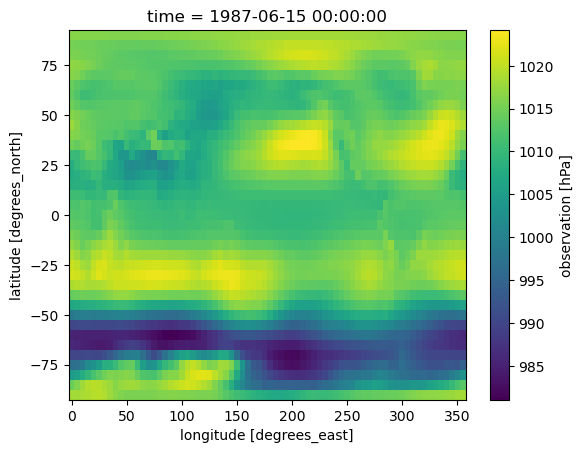

In [92]:
%%time
# Load or build the raw-value observation input required by direct RMSE.
obs_chunks = {'time': 24, 'lat': 90, 'lon': 180}
if use_prepared_direct_inputs:
    obs_prepared = workflow_resources.track(
        xr.open_dataset(obs_prepared_path, chunks=obs_chunks))
    obs_seas_rg = obs_prepared['observation']
else:
    obs_monthly = obs_access.get_monthly_data_from_pattern(
        cfg['obs_path_pattern'], field=cfg['obs_var'],
        start_year=cfg['obs_ys'], end_year=cfg['obs_ye'],
        chunks=obs_chunks, verbose=True)
    workflow_resources.track(obs_monthly)
    obs_seas = obs_access.mon_to_seas_obs(
        obs_monthly, var=cfg['obs_var'], field_map={field: cfg['obs_var']}
    ).chunk(obs_chunks)
    regridder_obs = regrid.make_regridder(
        obs_monthly, destgrid, method=regrid_method, periodic=regrid_periodic)
    try:
        obs_seas_rg = regridder_obs(obs_seas, output_chunks=obs_chunks)
    except TypeError:
        obs_seas_rg = regridder_obs(obs_seas)
    obs_seas_rg = cfg['obs_convert'](obs_seas_rg.chunk(obs_chunks))
    prepared = obs_seas_rg.rename('observation').to_dataset()
    prepared.attrs.update(obs_prepared_attrs)
    atomic_to_netcdf(prepared, obs_prepared_path, **seasonal_write_options)
    obs_prepared = workflow_resources.track(
        xr.open_dataset(obs_prepared_path, chunks=obs_chunks))
    obs_seas_rg = obs_prepared['observation']
print(f'Prepared observations: {obs_prepared_path}')
print(obs_seas_rg)
if cfg['obs_name'] == 'ERA5':
    obs_era5_seas_rg = obs_seas_rg
if field == 'PRECT':
    obs_gpcp_seas_rg = obs_seas_rg

if source_identity_mode == 'snapshot':
    print('Snapshot restart: observation preview omitted.')
else:
    obs_seas_rg.isel(time=min(100, obs_seas_rg.sizes['time'] - 1)).plot()


# RMSE Analysis

Compute model-vs-observation RMSE over the configured evaluation years using the ensemble mean forecast:

`RMSE = sqrt(mean_Y((ensemble_mean(model) - obs)^2))`

We also save bias, MAE, and the number of valid years at each grid point.


In [93]:
%%time
# Build model verification-time dictionaries.
# These are used to sample the observation seasonal means at the same verification seasons.

if "time_by_case_month" not in globals():
    # Recovery for kernels that ran the older cleanup code: reconstruct the
    # same authoritative verification times from initialization tags and leads.
    time_by_case_month = {
        case_key: {
            init_month: data_access._verification_time_from_init_tags(
                e3sm_da_by_case_month[case_key][init_month].Y.values,
                e3sm_da_by_case_month[case_key][init_month].L.values,
            )
            for init_month in init_months
        }
        for case_key in E3SM_CASES
    }

# The SMYLE time coordinates were preserved before raw seasonal-data cleanup.
# This fallback also lets this cell recover in a kernel holding the regridded arrays.
if "smyle_time_by_month" not in globals():
    smyle_time_by_month = {
        init_month: smyle_da_by_month[init_month].time.load()
        for init_month in init_months
    }

# Backward-compatible convenience variables for exploratory cells.
time_by_month = time_by_case_month[E3SM_REFERENCE_CASE]
e3smle05_time = time_by_month.get(5)
e3smle11_time = time_by_month.get(11)
smyle05_time = smyle_time_by_month.get(5)
smyle11_time = smyle_time_by_month.get(11)

print("Prepared verification-time arrays.")
for init_month in init_months:
    print(f"init_month={init_month}")
    print(f"  {E3SM_REFERENCE_CASE} time Y:", time_by_case_month[E3SM_REFERENCE_CASE][init_month].Y.values)
    if init_month in smyle_time_by_month:
        print("  CESM-SMYLE time Y:", smyle_time_by_month[init_month].Y.values)


Prepared verification-time arrays.
init_month=5
  E3SM-FOSIRL time Y: ['1980050100' '1981050100' '1982050100' '1983050100' '1984050100'
 '1985050100' '1986050100' '1987050100' '1988050100' '1989050100'
 '1990050100' '1991050100' '1992050100' '1993050100' '1994050100'
 '1995050100' '1996050100' '1997050100' '1998050100' '1999050100'
 '2000050100' '2001050100' '2002050100' '2003050100' '2004050100'
 '2005050100' '2006050100' '2007050100' '2008050100' '2009050100'
 '2010050100' '2011050100']
  CESM-SMYLE time Y: [1980 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1991 1992 1993
 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007
 2008 2009 2010 2011]
init_month=11
  E3SM-FOSIRL time Y: ['1980110100' '1981110100' '1982110100' '1983110100' '1984110100'
 '1985110100' '1986110100' '1987110100' '1988110100' '1989110100'
 '1990110100' '1991110100' '1992110100' '1993110100' '1994110100'
 '1995110100' '1996110100' '1997110100' '1998110100' '1999110100'
 '2000110100' '200111

In [94]:
%%time
# Helper functions for direct RMSE.
import importlib
importlib.reload(rmse_compare_helper)

DIRECT_RMSE_OUTDIRS = {
    model: str(root / field)
    for model, root in DIRECT_RMSE_ROOTS.items()
}
BOOT_RMSE_OUTDIRS = {
    model: os.path.join(output_dir, "bootstrap_rmse_diff")
    for model, output_dir in DIRECT_RMSE_OUTDIRS.items()
}
for output_dir in DIRECT_RMSE_OUTDIRS.values():
    os.makedirs(output_dir, exist_ok=True)

# Native rolling-window coordinates from mon_to_seas_dask are 3, 6, ..., 24.
# L=3 verifies two months after initialization; figure Lead-1 means months 1-3.
DIRECT_RMSE_LEADS = list(rmse_compare_helper.DIRECT_RMSE_LEADS)
map_plot_leads = DIRECT_RMSE_LEADS[:-1]
metric_units = cfg.get("units", "") if "cfg" in globals() else ""

normalize_Y_to_year = rmse_compare_helper.normalize_y_to_year
drop_non_dim_coords = rmse_compare_helper.drop_non_dim_coords
get_ensemble_mean = rmse_compare_helper.get_ensemble_mean
make_obs_like_model = rmse_compare_helper.make_obs_like_model_time
prepare_model_for_direct_rmse = rmse_compare_helper.prepare_model_for_direct_rmse
finite_fraction = rmse_compare_helper.finite_fraction
normalize_direct_rmse_leads = rmse_compare_helper.normalize_direct_rmse_leads
require_available_lead = rmse_compare_helper.require_available_lead
def safe_model_name(model):
    """Filename prefix for a model: its source folder name (E3SM cache tag or CESM-SMYLE)."""
    folder = E3SM_CASES[model]["cache_tag"] if model in E3SM_CASES else model
    return rmse_compare_helper.safe_model_name(folder)
valid_area_weighted_fraction = rmse_compare_helper.valid_area_weighted_fraction


def compute_direct_rmse(model_da, obs_da, model_time, common_years):
    return rmse_compare_helper.compute_direct_rmse(
        model_da=model_da,
        obs_da=obs_da,
        model_time=model_time,
        common_years=common_years,
        field=field,
        units=cfg["units"],
        lead_coord=DIRECT_RMSE_LEADS,
    )


def print_direct_rmse_input_check(label, model_da, obs_da, model_time, common_years):
    return rmse_compare_helper.print_direct_rmse_input_check(
        label=label,
        model_da=model_da,
        obs_da=obs_da,
        model_time=model_time,
        common_years=common_years,
    )

def direct_rmse_cache_spec(source, case_prefix, source_identity, init_month, common_years, ensemble_size):
    expected = rmse_compare_helper.direct_rmse_cache_attrs(
        source=source, source_data_identity=source_identity, case_prefix=case_prefix,
        variable=field, init_month=init_month, verification_years=common_years,
        observation_product=cfg['obs_name'], observation_variable=cfg['obs_var'],
        observation_data_identity=obs_source_identity, target_grid=TARGET_GRID_IDENTITY,
        regridding_method=regrid_method, ensemble_member_count=ensemble_size,
        lead_values=DIRECT_RMSE_LEADS, unit_conversion_version=UNIT_CONVERSION_VERSION)
    path = rmse_compare_helper.direct_rmse_cache_path(
        root=S2D_DIAG_ROOT, source=source, component=analysis_component, variable=field,
        init_month=init_month, verification_years=common_years, expected_attrs=expected)
    return path, expected

def load_current_direct_rmse_cache(path, expected):
    compatible, reason = cache_status(
        path, expected_attrs=expected, required_variables=('rmse', 'bias', 'mae', 'n_years'))
    if force_compute_direct_rmse or not compatible:
        if Path(path).exists():
            print(f'Recomputing incompatible direct-RMSE cache {path}: {reason}')
        return None
    return normalize_direct_rmse_leads(load_netcdf(path))


force_compute_direct_rmse = FORCE_COMPUTE_DIRECT_RMSE

UNIT_CONVERSION_VERSION = 'leadtime_rmse_units_v1'
TARGET_GRID_IDENTITY = f'latlon_{target_dlat}x{target_dlon}_periodic-{regrid_periodic}'
NETCDF_WRITE_OPTIONS = {
    'cleanup_temporary': WORKFLOW_SETTINGS['cache']['cleanup_temp_files'],
    'temp_file_max_age_hours': WORKFLOW_SETTINGS['cache']['temp_file_max_age_hours'],
}

print("Direct-RMSE helper functions are ready.")


Direct-RMSE helper functions are ready.
CPU times: user 7.1 ms, sys: 4.89 ms, total: 12 ms
Wall time: 81.6 ms


In [95]:
%%time
# Compute and save direct RMSE for CESM-SMYLE and all configured E3SM cases.
direct_rmse_smyle_by_month = {}
direct_rmse_e3sm_by_case_month = {}

# Observation data used for direct RMSE.
obs_direct = obs_seas_rg.chunk({"time": 24, "lat": 90, "lon": 180})

if not cfg.get("has_smyle_benchmark", True):
    print(f"Skipping the CESM-SMYLE direct-RMSE computation: no CESM-SMYLE benchmark is configured for field={field!r}.")
else:
    # ---------------------------------------------------------------------
    # CESM-SMYLE direct RMSE
    # ---------------------------------------------------------------------
    for init_month in init_months:
        common_years = SMYLE_MATCHED_YEARS_BY_MONTH[init_month]
        year_tag = compact_year_tag(common_years)

        out_nc, expected_attrs = direct_rmse_cache_spec(
            'CESM-SMYLE', 'b.e21.BSMYLE.f09_g17', smyle_source_identity_by_month[init_month],
            init_month, common_years, smyle_nens)

        ds_rmse = load_current_direct_rmse_cache(out_nc, expected_attrs)
        if ds_rmse is None:
            print_direct_rmse_input_check(
                label=f"CESM-SMYLE direct RMSE input, init_month={init_month}",
                model_da=smyle_da_by_month[init_month],
                obs_da=obs_direct,
                model_time=smyle_time_by_month[init_month],
                common_years=common_years,
            )

            ds_rmse = compute_direct_rmse(
                model_da=smyle_da_by_month[init_month],
                obs_da=obs_direct,
                model_time=smyle_time_by_month[init_month],
                common_years=common_years,
            ).compute()
            ds_rmse.attrs.update(expected_attrs)
            atomic_to_netcdf(ds_rmse, out_nc, **NETCDF_WRITE_OPTIONS)

        direct_rmse_smyle_by_month[init_month] = ds_rmse

        print("\nSaved/loaded:", out_nc)
        print(ds_rmse)


# ---------------------------------------------------------------------
# E3SM direct RMSE
# ---------------------------------------------------------------------
for case_key, case_info in E3SM_CASES.items():
    direct_rmse_e3sm_by_case_month[case_key] = {}

    for init_month in init_months:
        # Start from the reference-case/SMYLE matched years, then intersect with this E3SM case.
        requested_years = SMYLE_MATCHED_YEARS_BY_MONTH[init_month]
        model_years = [
            int(str(y)[:4])
            for y in e3sm_da_by_case_month[case_key][init_month]["Y"].values
        ]
        common_years = [y for y in requested_years if y in model_years]

        if len(common_years) == 0:
            raise ValueError(f"No common years for {case_key}, init_month={init_month}")

        year_tag = compact_year_tag(common_years)
        safe_case = safe_model_name(case_key)

        out_nc, expected_attrs = direct_rmse_cache_spec(
            case_info['cache_tag'], case_info['case_prefix'],
            e3sm_source_identity_by_case_month[case_key][init_month],
            init_month, common_years, case_nens)

        ds_rmse = load_current_direct_rmse_cache(out_nc, expected_attrs)
        if ds_rmse is None:
            print_direct_rmse_input_check(
                label=f"{case_key} direct RMSE input, init_month={init_month}",
                model_da=e3sm_da_by_case_month[case_key][init_month],
                obs_da=obs_direct,
                model_time=time_by_case_month[case_key][init_month],
                common_years=common_years,
            )

            ds_rmse = compute_direct_rmse(
                model_da=e3sm_da_by_case_month[case_key][init_month],
                obs_da=obs_direct,
                model_time=time_by_case_month[case_key][init_month],
                common_years=common_years,
            ).compute()
            ds_rmse.attrs.update(expected_attrs)
            atomic_to_netcdf(ds_rmse, out_nc, **NETCDF_WRITE_OPTIONS)

        direct_rmse_e3sm_by_case_month[case_key][init_month] = ds_rmse

        print("\nSaved/loaded:", out_nc)
        print(ds_rmse)


# Combined dictionary used by plotting cells.
direct_rmse_by_model = {
    **({"CESM-SMYLE": direct_rmse_smyle_by_month} if cfg.get("has_smyle_benchmark", True) else {}),
    **direct_rmse_e3sm_by_case_month,
}

# Backward-compatible aliases for exploratory cells.
skill_by_model = direct_rmse_by_model
skill_by_case_month = direct_rmse_e3sm_by_case_month
skill_by_month = direct_rmse_e3sm_by_case_month[E3SM_REFERENCE_CASE]
smyle_skill_by_month = direct_rmse_smyle_by_month

print("Finished direct-RMSE calculation.")



Saved/loaded: /global/cfs/cdirs/e3sm/S2S2D/s2d_diag/CESM-SMYLE/leadtime_acc/comparison/atm/direct_rmse/PSL/CESM-SMYLE_PSL_direct_rmse_init05_years_1980-2011_ny32.nc
<xarray.Dataset> Size: 299kB
Dimensions:  (L: 8, lat: 37, lon: 72)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
Data variables:
    rmse     (L, lat, lon) float32 85kB 15.91 15.91 16.12 16.66 ... nan nan nan
    bias     (L, lat, lon) float32 85kB -15.49 -15.5 -15.71 ... nan nan nan
    mae      (L, lat, lon) float32 85kB 15.49 15.5 15.71 16.26 ... nan nan nan
    n_years  (L, lat, lon) int16 43kB 32 32 32 32 32 32 32 32 ... 0 0 0 0 0 0 0
Attributes: (12/29)
    description:                      Direct model-vs-observation RMSE for li...
    field:                            PSL
    units:                            hPa
    skill_cache_version:        

In [96]:
%%time
# Optional sanity check: direct-RMSE finite fractions

for model_name, by_month in direct_rmse_by_model.items():
    for init_month, ds in by_month.items():
        print("\n" + "=" * 80)
        print(f"{model_name}, init_month={init_month}")
        for var in ["rmse", "bias", "mae", "n_years"]:
            finite_fraction(ds[var], f"{var}")

# Compute and save direct RMSE differences relative to reference_model.
# Negative rmse_diff means the E3SM case has lower RMSE than reference_model.

direct_rmse_diff_by_case_month = {}

for case_key in E3SM_CASES:
    if case_key == reference_model:
        continue
    direct_rmse_diff_by_case_month[case_key] = {}

    for init_month in init_months:
        if init_month not in direct_rmse_by_model[reference_model]:
            continue
        ds_diff = rmse_compare_helper.direct_rmse_difference(
            direct_rmse_e3sm_by_case_month[case_key][init_month],
            direct_rmse_by_model[reference_model][init_month],
        )
        ds_diff.attrs["description"] = (
            f"Direct RMSE difference and ratio relative to {reference_model}. "
            f"Negative rmse_diff or rmse_ratio < 1 indicates smaller RMSE than {reference_model}."
        )
        ds_diff.attrs["field"] = field
        ds_diff.attrs["units"] = cfg.get("units", "")

        direct_rmse_diff_by_case_month[case_key][init_month] = ds_diff

        year_tag = compact_year_tag(SMYLE_MATCHED_YEARS_BY_MONTH[init_month])
        safe_case = safe_model_name(case_key)
        safe_reference = safe_model_name(reference_model)

        out_nc = os.path.join(
            DIRECT_RMSE_OUTDIRS[case_key],
            f"{safe_case}_minus_{safe_reference}_{field}_direct_rmse_diff_init{init_month:02d}_years_{year_tag}.nc",
        )

        ds_diff.attrs['left_source_identity'] = e3sm_source_identity_by_case_month[case_key][init_month]
        ds_diff.attrs['right_source_identity'] = (
            smyle_source_identity_by_month[init_month] if reference_model == "CESM-SMYLE"
            else e3sm_source_identity_by_case_month[reference_model][init_month]
        )
        ds_diff.attrs['observation_data_identity'] = obs_source_identity
        ds_diff.attrs['cache_kind'] = 'direct_rmse_difference'
        atomic_to_netcdf(ds_diff, out_nc, **NETCDF_WRITE_OPTIONS)

        print("\n" + "=" * 80)
        print(f"{case_key}, init_month={init_month}")
        print("Saved:", out_nc)
        print(ds_diff)

print("Finished direct-RMSE difference calculation.")



CESM-SMYLE, init_month=5
rmse: finite fraction = 0.8750
rmse: dims=('L', 'lat', 'lon'), shape=(8, 37, 72)
rmse: L=[np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24)]
bias: finite fraction = 0.8750
bias: dims=('L', 'lat', 'lon'), shape=(8, 37, 72)
bias: L=[np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24)]
mae: finite fraction = 0.8750
mae: dims=('L', 'lat', 'lon'), shape=(8, 37, 72)
mae: L=[np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24)]
n_years: finite fraction = 1.0000
n_years: dims=('L', 'lat', 'lon'), shape=(8, 37, 72)
n_years: L=[np.int64(3), np.int64(6), np.int64(9), np.int64(12), np.int64(15), np.int64(18), np.int64(21), np.int64(24)]

CESM-SMYLE, init_month=11
rmse: finite fraction = 0.8750
rmse: dims=('L', 'lat', 'lon'), shape=(8, 37, 72)
rmse: L=[np.int64(3), np.int64(6), np.int64(9), np.int64(12), np

### Final RMSE Plot: reference_model vs E3SM

- Reads or uses saved direct-RMSE files for `reference_model` plus all configured E3SM cases.
- Plots each initialization month as grouped model columns.
- Uses direct model-vs-observation RMSE, not normalized RMSE from `compute_skill_seasonal`.


In [97]:
# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from cartopy.util import add_cyclic_point
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText

def seasonal_label(init_month, lead):
    center_month = ((init_month + lead - 2) % 12) + 1
    return season_names[((center_month % 12) // 3)]

def lead_label(init_month, lead):
    display_lead = lead - 2
    init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
    return f"Lead-{display_lead} {seasonal_label(init_month, lead)} ({init_label} init)"

def add_lat_lon_labels(ax, is_bottom, is_left):
    for spine in ax.spines.values():
        spine.set_linewidth(map_axis_linewidth)
    ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
    ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
    ax.yaxis.set_major_formatter(LatitudeFormatter())
    ax.tick_params(
        labelsize=lat_lon_label_size,
        length=lat_lon_tick_length, width=lat_lon_tick_width,
        top=False, right=False,
        labelbottom=is_bottom,
        labelleft=is_left,
    )
    ax.gridlines(
        crs=ccrs.PlateCarree(),
        linewidth=gridline_width,
        color=gridline_color, alpha=gridline_alpha, linestyle=gridline_style,
        draw_labels=False,
    )

def map_colorbar_settings(plot_type, field):
    config = MAP_COLORBAR_CONFIG[plot_type][field]
    levels = np.asarray(config["levels"], dtype=float)
    ticks = np.asarray(config["ticks"], dtype=float)
    steps = np.diff(levels)
    if levels.ndim != 1 or levels.size < 2 or np.any(steps <= 0):
        raise ValueError(f"Invalid colorbar levels for {plot_type}/{field}")
    if not np.allclose(steps, steps[0]):
        raise ValueError(
            f"Map helper requires uniform levels for {plot_type}/{field}"
        )
    if np.any(ticks < levels[0]) or np.any(ticks > levels[-1]):
        raise ValueError(f"Ticks outside levels for {plot_type}/{field}")
    return levels, ticks, int(config["decimals"])


# =============================================================================
# Setup parameters: Global direct RMSE map layout and styling
# =============================================================================
# Typography & font sizes
fontz = 14
panel_title_size = fontz
section_title_size = fontz * 1.15
lead_badge_size = fontz - 4.5
lat_lon_label_size = fontz - 3.5
colorbar_label_size = fontz
colorbar_tick_size = fontz - 2.5
suptitle_size = fontz * 1.3
fweight = "bold"

# Figure geometry and resolution
fig_width = 15.5
fig_height = 19.5
dpi = globals().get("dpi", 300)

# GridSpec spacing and section partition
gs_top = 0.915
gs_bottom = 0.055
gs_left = 0.065
gs_right = 0.975
gs_hspace = 0.22
gs_wspace = 0.09
middle_gap_ratio = 0.35

# Map coordinate ticks and gridlines
lon_ticks = [-160, -80, 0, 80, 160]
lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"

# Shading colormap and cutoff
cmap = "YlOrRd"
coff = 0.5
map_plot_leads = globals().get("map_plot_leads", DIRECT_RMSE_LEADS[:-1] if "DIRECT_RMSE_LEADS" in globals() else [3, 6, 9, 12, 15, 18, 21])
metric_units = cfg.get("units", "") if "cfg" in globals() else ""

# Colorbar placement and orientation
colorbar_axes = [0.25, 0.020, 0.5, 0.012]
colorbar_orientation = "horizontal"

# Section banners (Year 1 and Year 2)
banner_y_year1 = 0.945
banner_y_year2 = 0.490
banner_bbox = dict(boxstyle="round,pad=0.28", facecolor="#f0f4f8", edgecolor="#b0c4de", alpha=0.92, linewidth=1.0)

# Subplot badge styling (lead and verification season)
badge_loc = "lower left"
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)

# Verification season cohort configuration
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}
season_comparisons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]
# Keep only the configured initialization months (e.g. smoke mode runs November only).
season_comparisons = [spec for spec in season_comparisons if spec["init_month"] in init_months]


working on figure: fig_rmse_compare_psl_rmse_compare_global.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_psl_rmse_compare_global.png


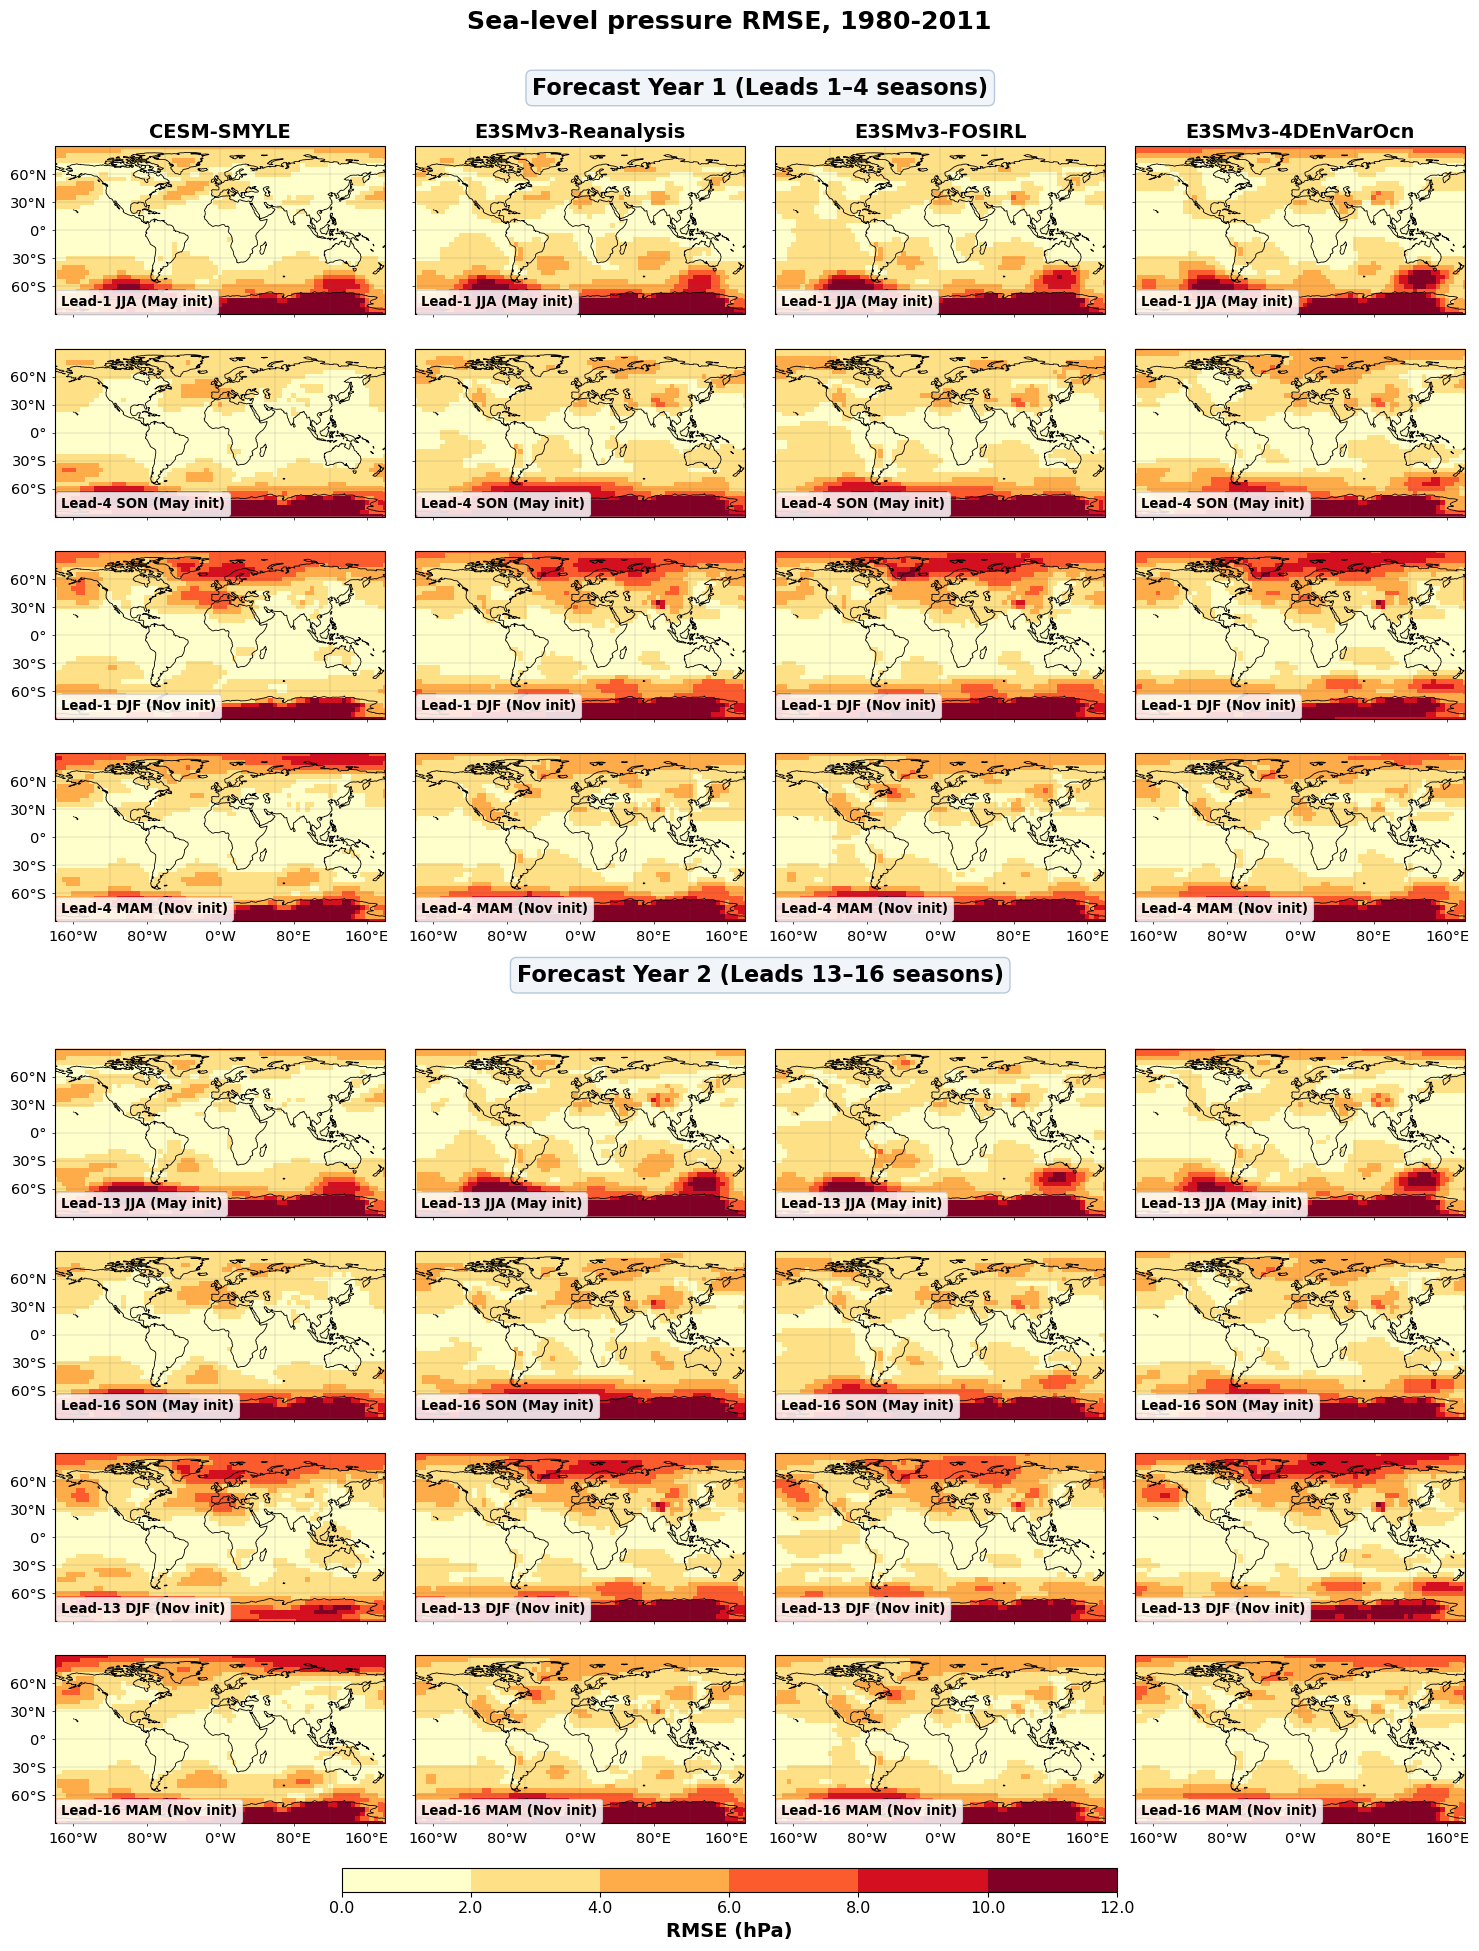

CPU times: user 7.36 s, sys: 687 ms, total: 8.05 s
Wall time: 7.7 s


In [98]:
%%time
abs_rmse_levels, abs_rmse_ticks, abs_rmse_decimals = map_colorbar_settings(
    "absolute_rmse", field
)
diff_levels, diff_ticks, diff_decimals = map_colorbar_settings(
    "rmse_difference", field
)
compact_year_tag = rmse_compare_helper.compact_year_tag

# Models to compare
model_order = (["CESM-SMYLE"] if cfg.get("has_smyle_benchmark", True) else []) + list(E3SM_CASES)
model_display_name = {"CESM-SMYLE": "CESM-SMYLE"}
model_display_name.update({
    case_key: case_info.get("display_name", case_key)
    for case_key, case_info in E3SM_CASES.items()
})

if "direct_rmse_by_model" not in globals():
    raise RuntimeError(
        "Run the direct-RMSE computation/cache-loading cell first; it validates "
        "the hashed cache path and provenance before plotting."
    )

rmse_plot_by_model = {
    model: {
        init_month: normalize_direct_rmse_leads(ds)
        for init_month, ds in by_month.items()
    }
    for model, by_month in direct_rmse_by_model.items()
}
skill_plot_by_model = rmse_plot_by_model

# Use the absolute-RMSE colorbar selected with `field` above
if "abs_rmse_levels" not in globals():
    abs_rmse_levels, abs_rmse_ticks, abs_rmse_decimals = map_colorbar_settings("absolute_rmse", field)
colorbar_levels = abs_rmse_levels
colorbar_ticks = abs_rmse_ticks
colorbar_tick_decimals = abs_rmse_decimals

if colorbar_levels.ndim != 1 or colorbar_levels.size < 2:
    raise ValueError("colorbar_levels must contain at least two values")
level_steps = np.diff(colorbar_levels)
if np.any(level_steps <= 0) or not np.allclose(level_steps, level_steps[0]):
    raise ValueError("colorbar_levels must be strictly increasing and uniformly spaced")
cmin = float(colorbar_levels[0])
cmax = float(colorbar_levels[-1])
ci = float(level_steps[0])

# Validate requested leads
for spec in season_comparisons:
    init_month = spec["init_month"]
    for model in model_order:
        if init_month not in rmse_plot_by_model[model]:
            raise KeyError(f"Missing {model} direct RMSE data for init_month={init_month}.")
        available = np.asarray(rmse_plot_by_model[model][init_month].L.values, dtype=int)
        missing = [lead for lead in spec["year_leads"] if lead not in available]
        if missing:
            raise ValueError(
                f"Missing leads {missing} for {model}, init_month={init_month}; "
                f"available={available.tolist()}"
            )

ncols = len(model_order)
nrows_per_year = len(season_comparisons)

metric = "RMSE"
metric_units = cfg.get("units", "")
metric_label = f"{metric} ({metric_units})" if metric_units else metric
subtitle = f"{cfg['plot_name']} RMSE, {years}-{yeare}"

figname = FIGURE_FILENAMES["compare_global"]
print(f"working on figure: {figname}")

fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(subtitle, fontsize=suptitle_size, fontweight=fweight, y=0.985)

# 9 GridSpec rows: 4 rows for Year 1, 1 gap row, 4 rows for Year 2
gs = fig.add_gridspec(
    nrows=9, ncols=ncols,
    height_ratios=[1, 1, 1, 1, middle_gap_ratio, 1, 1, 1, 1],
    top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
    hspace=gs_hspace, wspace=gs_wspace,
)

# Section banners
fig.text(0.52, banner_y_year1, "Forecast Year 1 (Leads 1–4 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)
fig.text(0.52, banner_y_year2, "Forecast Year 2 (Leads 13–16 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)

clevs = np.arange(cmin, cmax + ci, ci)
norm = BoundaryNorm(clevs, ncolors=plt.get_cmap(cmap).N, clip=True)
cntr = None

for year_idx in range(2):
    row_offset = 0 if year_idx == 0 else 5
    for r, spec in enumerate(season_comparisons):
        grid_row = row_offset + r
        init_month = spec["init_month"]
        season_str = spec["season"]
        lead = spec["year_leads"][year_idx]
        display_lead = lead - 2
        init_label = init_month_names.get(init_month, f"{init_month:02d}").title()
        badge_text = f"Lead-{display_lead} {season_str} ({init_label} init)"

        for c, model in enumerate(model_order):
            da_plot = rmse_plot_by_model[model][init_month]["rmse"].sel(L=lead)
            model_name = model_display_name.get(model, model)

            ax = fig.add_subplot(gs[grid_row, c], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            if grid_row == 0:
                ax.set_title(model_name, fontsize=panel_title_size, fontweight=fweight, pad=6)

            dat_cyc, lon_cyc = add_cyclic_point(da_plot.values, coord=da_plot.lon.values)
            cntr = ax.pcolormesh(
                lon_cyc, da_plot.lat.values, dat_cyc,
                shading="nearest", cmap=cmap, norm=norm,
                rasterized=True, transform=ccrs.PlateCarree(),
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

            b = AnchoredText(
                badge_text, loc=badge_loc,
                prop=dict(size=lead_badge_size, weight="bold", family="sans-serif"),
                frameon=True, pad=badge_pad, borderpad=badge_borderpad,
            )
            b.patch.set(**badge_bbox)
            ax.add_artist(b)

            is_bottom = (grid_row == 3) or (grid_row == 8)
            is_left = (c == 0)
            add_lat_lon_labels(ax, is_bottom=is_bottom, is_left=is_left)

cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(colorbar_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{colorbar_tick_decimals}f")
)
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="rmse_compare",
    title=f"RMSE Comparison: {field}",
    caption="Global RMSE comparison across E3SM and CESM-SMYLE hindcasts",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

In [99]:
# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText

def subset_conus(da):
    if float(da.lon.max()) > 180:
        da = da.sel(lon=slice(235, 294))
        da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
        da = da.sortby("lon")
    else:
        da = da.sel(lon=slice(conus_extent[0], conus_extent[1]))

    lat_slice = slice(conus_extent[2], conus_extent[3])
    if da.lat.size > 1 and float(da.lat[0]) > float(da.lat[-1]):
        lat_slice = slice(conus_extent[3], conus_extent[2])
    return da.sel(lat=lat_slice)

def add_conus_features(ax):
    for feature, kwargs in [
        (cfeature.COASTLINE, {"linewidth": 0.6}),
        (cfeature.BORDERS, {"linewidth": 0.4}),
        (cfeature.STATES, {"linewidth": 0.25, "edgecolor": "0.35"}),
    ]:
        try:
            ax.add_feature(feature, **kwargs)
        except Exception as err:
            print(f"Skipping Cartopy feature {feature}: {err}")

def conus_weighted_mean(da):
    weights = np.cos(np.deg2rad(da.lat))
    return float(da.weighted(weights).mean(("lat", "lon"), skipna=True))


# =============================================================================
# Setup parameters: CONUS Regional direct RMSE map layout and styling
# =============================================================================
# Typography & font sizes
fontz = 14
panel_title_size = fontz
section_title_size = fontz * 1.15
lead_badge_size = fontz - 4.5
lat_lon_tick_size = fontz - 3.5
colorbar_label_size = fontz
colorbar_tick_size = fontz - 2.5
suptitle_size = fontz * 1.3
fweight = "bold"

# Regional map domain and coordinate ticks
conus_extent = [-125, -66, 24, 50]
lon_ticks = [-120, -105, -90, -75]
lat_ticks = [25, 35, 45]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8

# Figure geometry and resolution
fig_width = 15.5
fig_height = 19.5
dpi = globals().get("dpi", 300)

# GridSpec spacing and section partition
gs_top = 0.915
gs_bottom = 0.055
gs_left = 0.065
gs_right = 0.975
gs_hspace = 0.22
gs_wspace = 0.09
middle_gap_ratio = 0.35

# Colorbar levels, placement and colormap
conus_cmap = "YlOrRd"
if "abs_rmse_levels" not in globals():
    abs_rmse_levels, abs_rmse_ticks, abs_rmse_decimals = map_colorbar_settings("absolute_rmse", field)
conus_colorbar_levels = abs_rmse_levels
conus_colorbar_ticks = abs_rmse_ticks
conus_colorbar_tick_decimals = abs_rmse_decimals

colorbar_axes = [0.25, 0.020, 0.5, 0.012]
colorbar_orientation = "horizontal"

# Section banners (Year 1 and Year 2)
banner_y_year1 = 0.945
banner_y_year2 = 0.490
banner_bbox = dict(boxstyle="round,pad=0.28", facecolor="#f0f4f8", edgecolor="#b0c4de", alpha=0.92, linewidth=1.0)

# Subplot badge styling
badge_loc = "lower left"
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="lightgray", alpha=0.85, linewidth=0.8)

# Verification season cohort configuration
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "JAN", 2: "FEB", 3: "MAR", 4: "APR", 5: "MAY", 6: "JUN",
    7: "JUL", 8: "AUG", 9: "SEP", 10: "OCT", 11: "NOV", 12: "DEC",
}
conus_seasons = [
    {"season": "JJA", "init_month": 5, "year_leads": [3, 15]},
    {"season": "SON", "init_month": 5, "year_leads": [6, 18]},
    {"season": "DJF", "init_month": 11, "year_leads": [3, 15]},
    {"season": "MAM", "init_month": 11, "year_leads": [6, 18]},
]
# Keep only the configured initialization months (e.g. smoke mode runs November only).
conus_seasons = [spec for spec in conus_seasons if spec["init_month"] in init_months]
# Keep only the configured initialization months (e.g. smoke mode runs November only).
season_comparisons = [spec for spec in season_comparisons if spec["init_month"] in init_months]

conus_models = (["CESM-SMYLE"] if cfg.get("has_smyle_benchmark", True) else []) + list(E3SM_CASES)
model_display_name = {"CESM-SMYLE": "CESM-SMYLE"}
model_display_name.update({
    case_key: case_info.get("display_name", case_key)
    for case_key, case_info in E3SM_CASES.items()
})



working on figure: fig_rmse_compare_psl_rmse_compare_conus.png
Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_psl_rmse_compare_conus.png


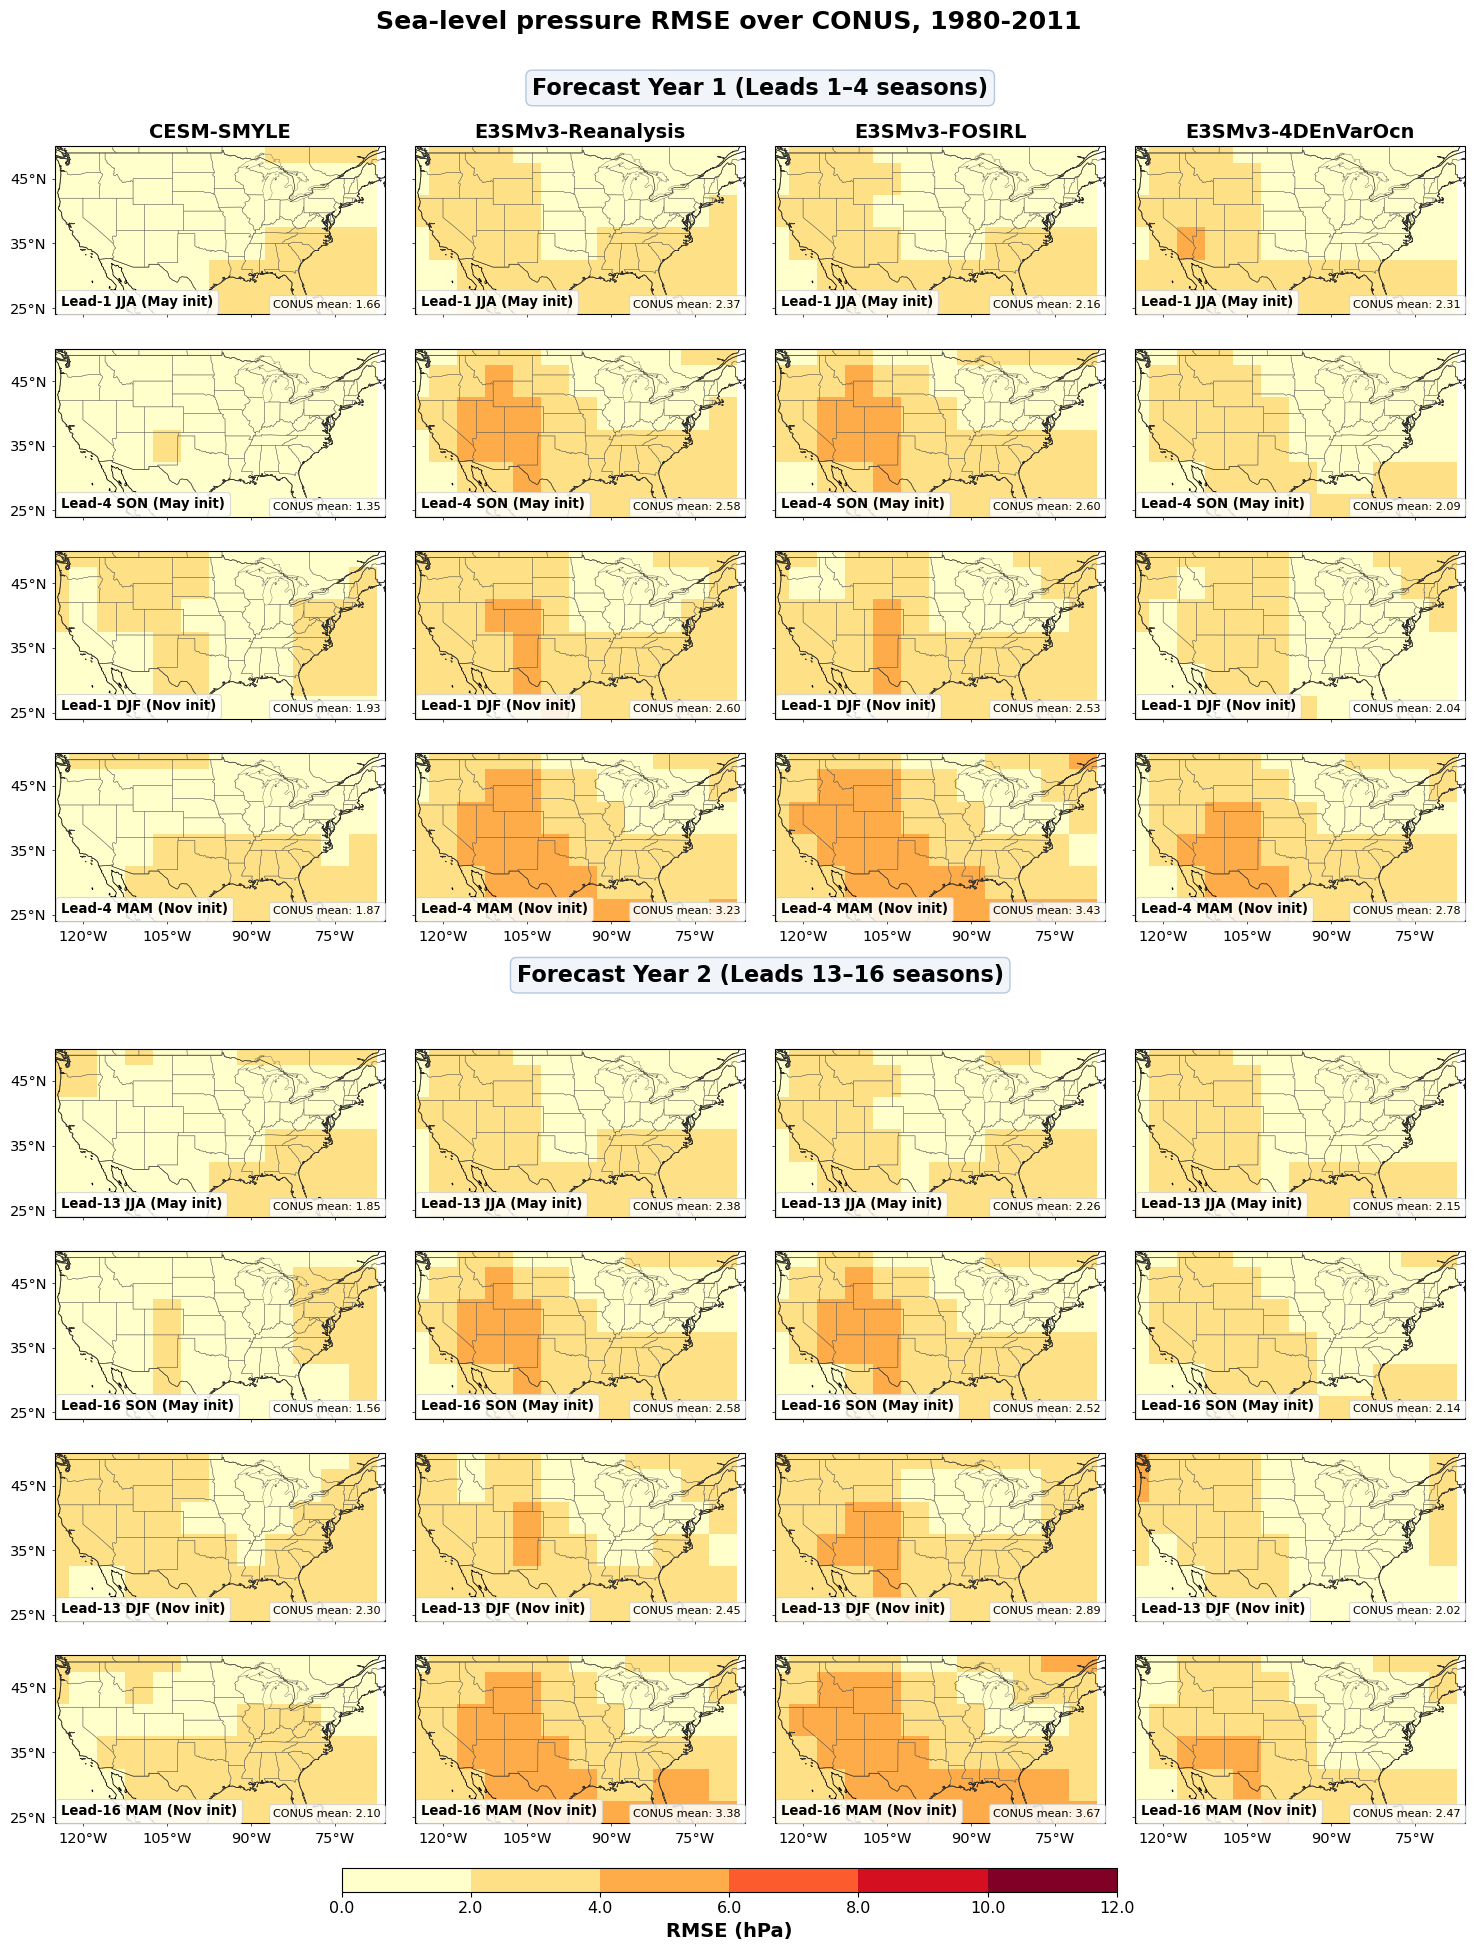

CPU times: user 5.86 s, sys: 661 ms, total: 6.53 s
Wall time: 6.27 s


In [100]:
%%time
if "direct_rmse_by_model" not in globals():
    raise RuntimeError(
        "Run the direct-RMSE computation/cache-loading cell first; it validates "
        "the hashed cache path and provenance before plotting."
    )

if "rmse_plot_by_model" not in globals():
    rmse_plot_by_model = {
        model: {
            init_month: normalize_direct_rmse_leads(ds)
            for init_month, ds in by_month.items()
        }
        for model, by_month in direct_rmse_by_model.items()
    }

conus_fields = {model: {} for model in conus_models}
conus_actual_leads = {model: {} for model in conus_models}
for model in conus_models:
    for spec in conus_seasons:
        season_name = spec["season"]
        init_month = spec["init_month"]
        if init_month not in rmse_plot_by_model[model]:
            raise KeyError(f"Missing {model} direct RMSE for init_month={init_month}.")
        rmse_da = rmse_plot_by_model[model][init_month]["rmse"]
        conus_fields[model][season_name] = {}
        conus_actual_leads[model][season_name] = {}
        for target_lead in spec["year_leads"]:
            actual_lead = require_available_lead(rmse_da, target_lead)
            conus_actual_leads[model][season_name][target_lead] = actual_lead
            conus_fields[model][season_name][target_lead] = subset_conus(
                rmse_da.sel(L=actual_lead)
            )

conus_cmap_obj = plt.get_cmap(conus_cmap)
conus_norm = BoundaryNorm(conus_colorbar_levels, conus_cmap_obj.N, clip=False)

metric = "RMSE"
metric_units = cfg.get("units", "")
metric_label = f"{metric} ({metric_units})" if metric_units else metric
conus_subtitle = f"{cfg['plot_name']} RMSE over CONUS, {years}-{yeare}"

ncols = len(conus_models)
figname = FIGURE_FILENAMES["compare_conus"]
print(f"working on figure: {figname}")

fig = plt.figure(figsize=(fig_width, fig_height))
fig.suptitle(conus_subtitle, fontsize=suptitle_size, fontweight=fweight, y=0.985)

gs = fig.add_gridspec(
    nrows=9, ncols=ncols,
    height_ratios=[1, 1, 1, 1, middle_gap_ratio, 1, 1, 1, 1],
    top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
    hspace=gs_hspace, wspace=gs_wspace,
)

# Section banners
fig.text(0.52, banner_y_year1, "Forecast Year 1 (Leads 1–4 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)
fig.text(0.52, banner_y_year2, "Forecast Year 2 (Leads 13–16 seasons)", ha="center", va="center",
         fontsize=section_title_size, fontweight=fweight, bbox=banner_bbox)

cntr = None
for year_idx in range(2):
    row_offset = 0 if year_idx == 0 else 5
    for r, spec in enumerate(conus_seasons):
        grid_row = row_offset + r
        season_str = spec["season"]
        init_month = spec["init_month"]
        target_lead = spec["year_leads"][year_idx]
        init_label = init_month_names.get(init_month, f"{init_month:02d}").title()

        for c, model in enumerate(conus_models):
            da = conus_fields[model][season_str][target_lead]
            actual_lead = conus_actual_leads[model][season_str][target_lead]
            display_lead = actual_lead - 2
            badge_text = f"Lead-{display_lead} {season_str} ({init_label} init)"
            model_name = model_display_name.get(model, model)

            ax = fig.add_subplot(gs[grid_row, c], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            if grid_row == 0:
                ax.set_title(model_name, fontsize=panel_title_size, fontweight=fweight, pad=6)

            cntr = ax.pcolormesh(
                da.lon, da.lat, da,
                shading="nearest", cmap=conus_cmap_obj, norm=conus_norm,
                rasterized=True, transform=ccrs.PlateCarree(),
            )
            ax.set_extent(conus_extent, crs=ccrs.PlateCarree())
            add_conus_features(ax)

            # Lead badge in lower-left
            b = AnchoredText(
                badge_text, loc=badge_loc,
                prop=dict(size=lead_badge_size, weight="bold", family="sans-serif"),
                frameon=True, pad=badge_pad, borderpad=badge_borderpad,
            )
            b.patch.set(**badge_bbox)
            ax.add_artist(b)

            # CONUS mean in lower-right
            mean_text = f"CONUS mean: {conus_weighted_mean(da):.2f}"
            sb = AnchoredText(
                mean_text, loc="lower right",
                prop=dict(size=lead_badge_size * 0.85, weight="medium", family="sans-serif"),
                frameon=True, pad=badge_pad, borderpad=badge_borderpad,
            )
            sb.patch.set(**badge_bbox)
            ax.add_artist(sb)

            for spine in ax.spines.values():
                spine.set_linewidth(map_axis_linewidth)

            is_bottom = (grid_row == 3) or (grid_row == 8)
            is_left = (c == 0)

            ax.set_xticks(lon_ticks, crs=ccrs.PlateCarree())
            ax.set_yticks(lat_ticks, crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(
                labelsize=lat_lon_tick_size,
                length=lat_lon_tick_length, width=lat_lon_tick_width,
                top=False, right=False,
                labelbottom=is_bottom, labelleft=is_left,
            )

cbar_ax = fig.add_axes(colorbar_axes)
cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=colorbar_orientation)
cbar.set_ticks(conus_colorbar_ticks)
cbar.ax.xaxis.set_major_formatter(
    mticker.FormatStrFormatter(f"%.{conus_colorbar_tick_decimals}f")
)
cbar.set_label(metric_label, fontsize=colorbar_label_size, fontweight=fweight)
cbar.ax.tick_params(labelsize=colorbar_tick_size)

figpath = FIGURE_OUTDIR / figname
mov.save_figure(
    fig, figpath,
    mode="",
    metric="rmse_compare",
    title=f"CONUS RMSE Comparison: {field}",
    caption="CONUS RMSE comparison across E3SM and CESM-SMYLE hindcasts",
    dpi=dpi,
)
print("Saved figure:", figpath)
plt.show()

### Finite-ensemble RMSE comparison following the ACC workflow

For every enabled E3SM case with a strictly smaller ensemble than `reference_model`, this follows the finite-ensemble method in the ACC workflow: hold the smaller ensemble fixed and repeatedly sample the larger reference ensemble down to that size without replacement. Verification years are held fixed.

This method cannot provide a finite-ensemble significance test between two equal-size ensembles (e.g. two 10-member E3SM cases): resampling all members without replacement has no variance. Those comparisons are plotted without significance markers.


In [101]:
# Comparison work restarts independently for every case/month cache.
# Finite-ensemble RMSE comparison following the method in 1_ref*.
# Saves compact probability files used by the final comparison figures.
#
# Negative rmse_diff means the left-hand model has lower RMSE.
#
# The smaller E3SM ensemble is fixed. The larger CESM-SMYLE ensemble is
# repeatedly sampled without replacement to the E3SM member count. Years are
# held fixed, matching the finite-ensemble comparison used for ACC in 1_ref*.

import os
import glob
import numpy as np
import xarray as xr

def bootstrap_model_data(model, init_month):
    if model == "CESM-SMYLE":
        return smyle_da_by_month[init_month]
    return e3sm_da_by_case_month[model][init_month]

NBOOT = N_RESAMPLES  # compatibility alias used by downstream plotting cells

obs_compare_chunks = {
    k: v for k, v in {
        "time": 24,
        "lat": 90,
        "lon": 180,
    }.items()
    if k in obs_seas_rg.dims
}

for output_dir in BOOT_RMSE_OUTDIRS.values():
    os.makedirs(output_dir, exist_ok=True)
    


In [102]:
%%time
# ---------------------------------------------------------------------
# Prepare observation data
# ---------------------------------------------------------------------
# obs_seas_rg is time-dimensional: (time, lat, lon)
# Convert it to hindcast-style dimensions: (Y, L, lat, lon)
obs_compare = obs_seas_rg.chunk(obs_compare_chunks)

print("Created raw obs_compare:")
print(obs_compare)
print("obs_compare dims:", obs_compare.dims)


# Shared helper builds Y,L observations using the native seasonal convention:
# L=3 verifies at initialization month + 2 months, L=6 at +5 months, etc.
obs_compare_by_month = {}
for init_month in init_months:
    years = SMYLE_MATCHED_YEARS_BY_MONTH[init_month]
    template = (
        smyle_da_by_month[init_month] if reference_model == "CESM-SMYLE"
        else e3sm_da_by_case_month[reference_model][init_month]
    )
    leads = template["L"].values if BOOT_LEADS is None else BOOT_LEADS

    obs_compare_by_month[init_month] = rmse_compare_helper.make_obs_like_model_leads(
        obs_da=obs_compare,
        template_da=template,
        init_month=init_month,
        years=years,
        leads=leads,
    )

    print(f"\nOBS converted for init_month={init_month}")
    print(obs_compare_by_month[init_month])
    print("Y:", obs_compare_by_month[init_month]["Y"].values)
    print("L:", obs_compare_by_month[init_month]["L"].values)


# ---------------------------------------------------------------------
# Shared finite-ensemble helpers
# ---------------------------------------------------------------------
prepare_member_error = rmse_compare_helper.prepare_member_error
finite_ensemble_rmse_comparison_memorysafe = (
    rmse_compare_helper.finite_ensemble_rmse_comparison_memorysafe
)


# ---------------------------------------------------------------------
# The finite-ensemble method needs the reference ensemble strictly larger
# than the compared case (it resamples the reference down to the case
# size); with equal-size ensembles the resampling has no variance and the
# significance test is degenerate, so those pairs are skipped here and
# plotted without stippling by the downstream comparison cells instead.
# ---------------------------------------------------------------------
BOOT_COMPARISONS = [
    (case_key, reference_model) for case_key in E3SM_CASES
    if case_key != reference_model and reference_nens > case_nens
]
skipped_equal_size_comparisons = [
    case_key for case_key in E3SM_CASES
    if case_key != reference_model and reference_nens <= case_nens
]
if skipped_equal_size_comparisons:
    print(
        f"Skipping finite-ensemble significance test against {reference_model!r} "
        f"(ensemble size {reference_nens}) for {skipped_equal_size_comparisons}: "
        "reference ensemble is not larger, so resampling has no variance."
    )

bootstrap_rmse_diff_by_pair_month = {}

for left_model, right_model in BOOT_COMPARISONS:
    pair_key = f"{left_model}_minus_{right_model}"
    pair_output_dir = BOOT_RMSE_OUTDIRS[left_model]
    bootstrap_rmse_diff_by_pair_month[pair_key] = {}

    for init_month in init_months:
        common_years = SMYLE_MATCHED_YEARS_BY_MONTH[init_month]
        obs_da_this_month = obs_compare_by_month[init_month]

        safe_left = safe_model_name(left_model)
        safe_right = safe_model_name(right_model)
        year_tag = compact_year_tag(common_years)
        out_nc = os.path.join(
            pair_output_dir,
            f"{safe_left}_minus_{safe_right}_{field}_finite_ensemble_resampling_"
            f"init{init_month:02d}_years_{year_tag}_niter{N_RESAMPLES}.nc",
        )

        comparison_identity = {
            'field': field, 'left_model': left_model, 'right_model': right_model,
            'init_month': init_month, 'verification_years': list(map(int, common_years)),
            'sample_size': case_nens, 'iterations': N_RESAMPLES,
            'left_source_identity': e3sm_source_identity_by_case_month[left_model][init_month],
            'right_source_identity': (
                smyle_source_identity_by_month[init_month] if reference_model == "CESM-SMYLE"
                else e3sm_source_identity_by_case_month[reference_model][init_month]
            ),
            'observation_data_identity': obs_source_identity,
        }
        derived_seed = stable_resampling_seed(BOOT_RANDOM_SEED, comparison_identity)
        generated_indices = generate_member_indices(
            population_size=reference_nens, sample_size=case_nens,
            iterations=N_RESAMPLES, seed=derived_seed)
        selection_attrs = member_selection_attrs(
            base_seed=BOOT_RANDOM_SEED, derived_seed=derived_seed,
            identity=comparison_identity, member_indices=generated_indices)
        selection_path = Path(pair_output_dir) / (Path(out_nc).stem + '_member_indices.nc')
        selected_members = load_or_write_member_selection(
            selection_path, generated_indices, selection_attrs, reference_nens,
            force=FORCE_COMPUTE_BOOTSTRAP, write_options=NETCDF_WRITE_OPTIONS)
        expected_boot_attrs = {
            'cache_kind': 'finite_ensemble_direct_rmse',
            'comparison_identity_digest': selection_attrs['resampling_identity_digest'],
            'member_selection_checksum': selection_attrs['member_selection_checksum'],
            'observation_data_identity': obs_source_identity,
            'rmse_significance_version': rmse_compare_helper.RMSE_SIGNIFICANCE_VERSION,
        }
        compatible, reason = cache_status(
            out_nc, expected_attrs=expected_boot_attrs,
            required_variables=('rmse_diff', 'prob_left_lower_rmse',
                                'p_two_sided_resampling', 'left_better', 'right_better'))

        if compatible and not FORCE_COMPUTE_BOOTSTRAP:
            print("\n" + "=" * 80)
            print("Using existing bootstrap file:", out_nc)
            ds_boot = normalize_direct_rmse_leads(load_netcdf(out_nc))
            valid_comparison = (
                direct_rmse_by_model[left_model][init_month]["rmse"].notnull()
                & direct_rmse_by_model[right_model][init_month]["rmse"].notnull()
            )
            ds_boot = ds_boot.where(valid_comparison)
            bootstrap_rmse_diff_by_pair_month[pair_key][init_month] = ds_boot
            continue
        print(f'Recomputing {out_nc}: {reason}')

        left_err = prepare_member_error(
            model_da=bootstrap_model_data(left_model, init_month),
            obs_da=obs_da_this_month,
            common_years=common_years,
        )

        right_err = prepare_member_error(
            model_da=bootstrap_model_data(right_model, init_month),
            obs_da=obs_da_this_month,
            common_years=common_years,
        )

        print("\n" + "=" * 80)
        print(f"{left_model} minus {right_model}, init_month={init_month}")
        print("common_years:", common_years)
        print("obs dims:", obs_da_this_month.dims, obs_da_this_month.shape)
        print("obs Y:", obs_da_this_month["Y"].values)
        print("obs L:", obs_da_this_month["L"].values)
        print("left error dims:", left_err.dims, left_err.shape)
        print("right error dims:", right_err.dims, right_err.shape)

        ds_boot = finite_ensemble_rmse_comparison_memorysafe(
            left_err=left_err,
            right_err=right_err,
            n_iterations=N_RESAMPLES,
            seed=derived_seed,
            alpha=BOOT_ALPHA,
            member_indices=selected_members,
        )

        ds_boot.attrs["left_model"] = left_model
        ds_boot.attrs["right_model"] = right_model
        ds_boot.attrs.update(expected_boot_attrs)
        bootstrap_rmse_diff_by_pair_month[pair_key][init_month] = ds_boot
        atomic_to_netcdf(ds_boot, out_nc, **NETCDF_WRITE_OPTIONS)

        print("Saved:", out_nc)
        print(ds_boot)


Created raw obs_compare:
<xarray.DataArray 'observation' (time: 490, lat: 37, lon: 72)> Size: 5MB
dask.array<open_dataset-observation, shape=(490, 37, 72), dtype=float32, chunksize=(24, 37, 72), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 4kB 1979-02-15 00:00:00 ... 2019-11-15 00:00:00
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0 80.0 85.0 90.0
  * lon      (lon) float64 576B 0.0 5.0 10.0 15.0 ... 340.0 345.0 350.0 355.0
Attributes:
    regrid_method:  conservative
    units:          hPa
obs_compare dims: ('time', 'lat', 'lon')

OBS converted for init_month=5
<xarray.DataArray 'observation' (Y: 32, L: 8, lat: 37, lon: 72)> Size: 3MB
dask.array<rechunk-merge, shape=(32, 8, 37, 72), dtype=float32, chunksize=(4, 8, 37, 72), chunktype=numpy.ndarray>
Coordinates:
  * Y        (Y) int64 256B 1980 1981 1982 1983 1984 ... 2008 2009 2010 2011
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * lat      (lat) float64 296B -90.0 -85.0 -80.0 -75.0 ... 75.0

### Three-column RMSE difference comparison (Separate Figures by Initialization Month)

This plots each E3SM minus `reference_model` direct-RMSE difference column as a separate figure for each initialization month (May and November), one column per other enabled E3SM case.


In [103]:
# =============================================================================
# Execution: Imports, helper functions, data assembly and plotting
# =============================================================================
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from cartopy.util import add_cyclic_point
from esp_lab.utils import colormap_utils as mycolors
from matplotlib.colors import BoundaryNorm
from matplotlib.offsetbox import AnchoredText
import os
import numpy as np
import xarray as xr

def direct_rmse_filename(model, init_month):
    year_tag = compact_year_tag(SMYLE_MATCHED_YEARS_BY_MONTH[init_month])
    return os.path.join(
        DIRECT_RMSE_OUTDIRS[model],
        f"{safe_model_name(model)}_{field}_direct_rmse_init{init_month:02d}_years_{year_tag}.nc",
    )

# =============================================================================
# Setup parameters: Multi-column direct RMSE difference layout and styling
# (Generates separate 3-column figures for May and November initializations)
# =============================================================================
# Typography & font sizes
compare_fontz = 18
compare_panel_title_size = compare_fontz * 1.0 
compare_lead_badge_size = compare_fontz * 0.9
compare_score_badge_size = compare_fontz * 0.9
compare_lat_lon_label_size = compare_fontz * 0.9
compare_colorbar_label_size = compare_fontz * 0.9
compare_colorbar_tick_size = compare_fontz * 0.9
compare_suptitle_size = compare_fontz * 1.0
compare_legend_font_size = compare_fontz * 0.9

compare_fweight = "bold"
map_plot_leads = globals().get(
    "map_plot_leads",
    DIRECT_RMSE_LEADS[:-1] if "DIRECT_RMSE_LEADS" in globals() else [3, 6, 9, 12, 15, 18, 21],
)
metric_units = cfg.get("units", "") if "cfg" in globals() else ""

# Figure geometry and resolution (sized for 3 columns x 7 rows per figure)
fig_width = 17.5
dpi = globals().get("dpi", 300)
compare_suptitle_y = 0.982

# GridSpec spacing
gs_top = 0.920
gs_bottom = 0.055
gs_left = 0.060
gs_right = 0.980
gs_hspace = 0.18
gs_wspace = 0.06

# Map coordinate ticks and gridlines
compare_lon_ticks = [-160, -80, 0, 80, 160]
compare_lat_ticks = [-60, -30, 0, 30, 60]
lat_lon_tick_length = 2.5
lat_lon_tick_width = 0.5
map_axis_linewidth = 0.8
gridline_width = 0.35
gridline_color = "0.35"
gridline_alpha = 0.35
gridline_style = "-"
coastline_linewidth = 0.6
latlim = 80

# Significance marker and stippling controls
PLOT_MATCHED_ENSEMBLE_MARKERS = True
COMPARE_PROBABILITY_THRESHOLD = 0.9
NBOOT = globals().get("NBOOT", 1000)

compare_marker_stride = 1
compare_open_marker_size = 8
compare_filled_marker_size = 4
compare_marker_linewidth = 0.5
compare_marker_color = "black"

# Significance legend header banner
legend_x = 0.520
legend_y = 0.955
legend_bbox = dict(
    boxstyle="square,pad=0.25",
    facecolor="#ffffff",
    edgecolor="#cccccc",
    alpha=0.85,
    linewidth=0.6,
)

# Subplot badge styling
badge_pad = 0.18
badge_borderpad = 0.25
badge_bbox = dict(
    boxstyle="round,pad=0.2",
    facecolor="white",
    edgecolor="lightgray",
    alpha=0.88,
    linewidth=0.7,
)

# Colorbar placement and level configuration
compare_colorbar_axes = [0.28, 0.018, 0.44, 0.012]
compare_colorbar_orientation = "horizontal"
if "diff_levels" not in globals():
    diff_levels, diff_ticks, diff_decimals = map_colorbar_settings("rmse_difference", field)
diff_level_steps = np.diff(diff_levels)
cmin = float(diff_levels[0])
cmax = float(diff_levels[-1])
ci = float(diff_level_steps[0])
nlevs = int(round((cmax - cmin) / ci)) + 1
clevs = np.arange(cmin, cmax + ci, ci)
colorbar_ticks = diff_ticks
colorbar_tick_decimals = diff_decimals

# Season & month naming
season_names = ["DJF", "MAM", "JJA", "SON"]
init_month_names = {
    1: "January", 2: "February", 3: "March", 4: "April", 5: "May", 6: "June",
    7: "July", 8: "August", 9: "September", 10: "October", 11: "November", 12: "December",
}


Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_psl_rmse_difference_compare_init05.png


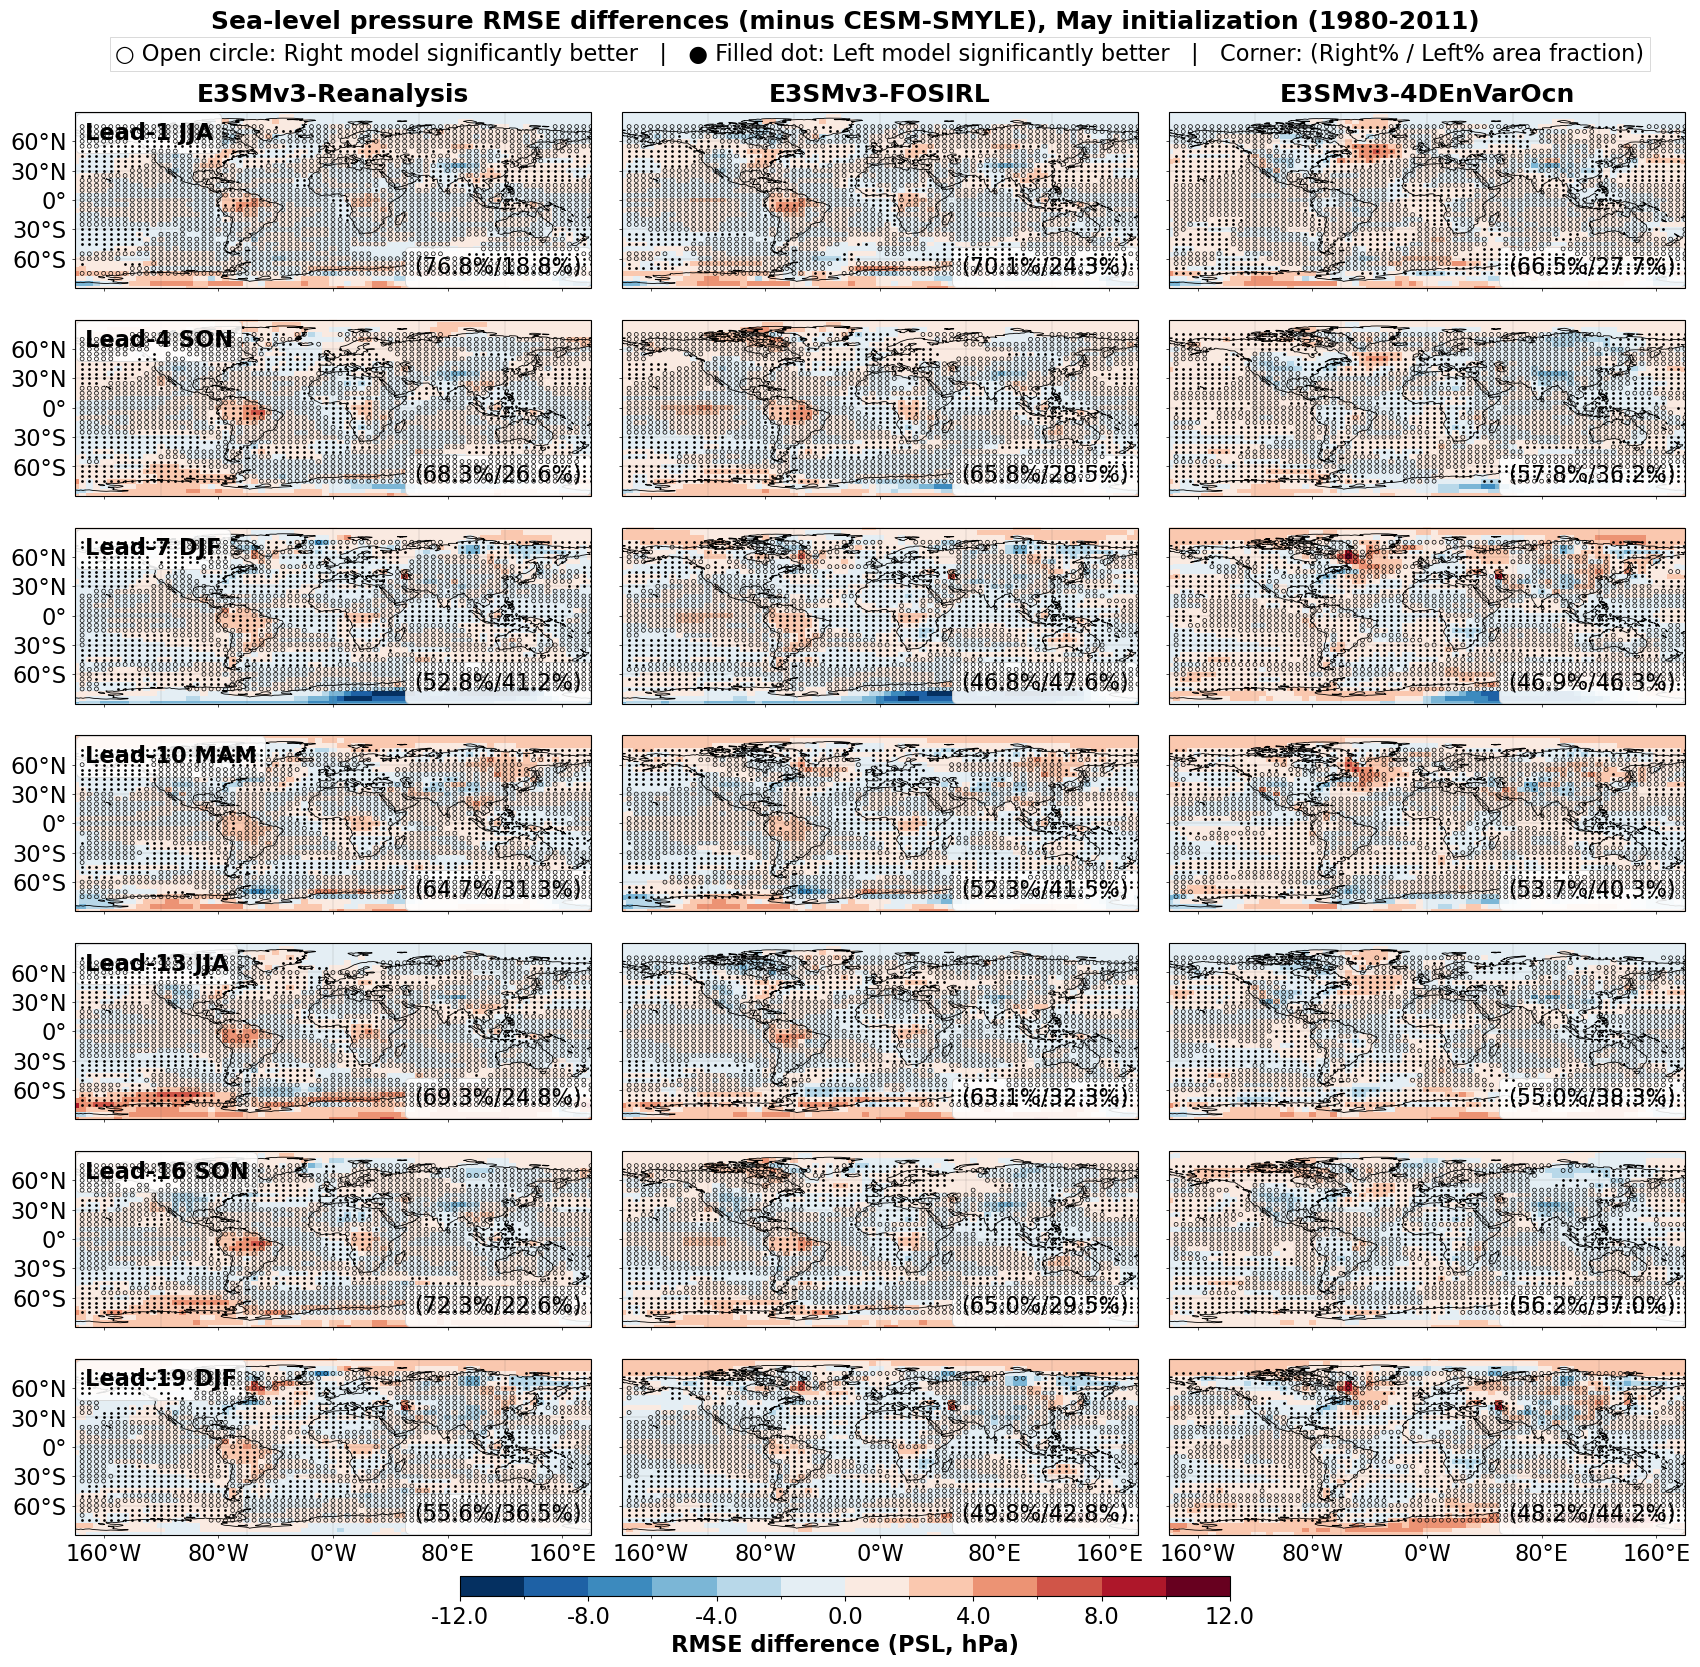

Saved figure: /global/cfs/cdirs/e3sm/www/zhan391/e3sm-s2d_diag/fig_rmse_compare_psl_rmse_difference_compare_init11.png


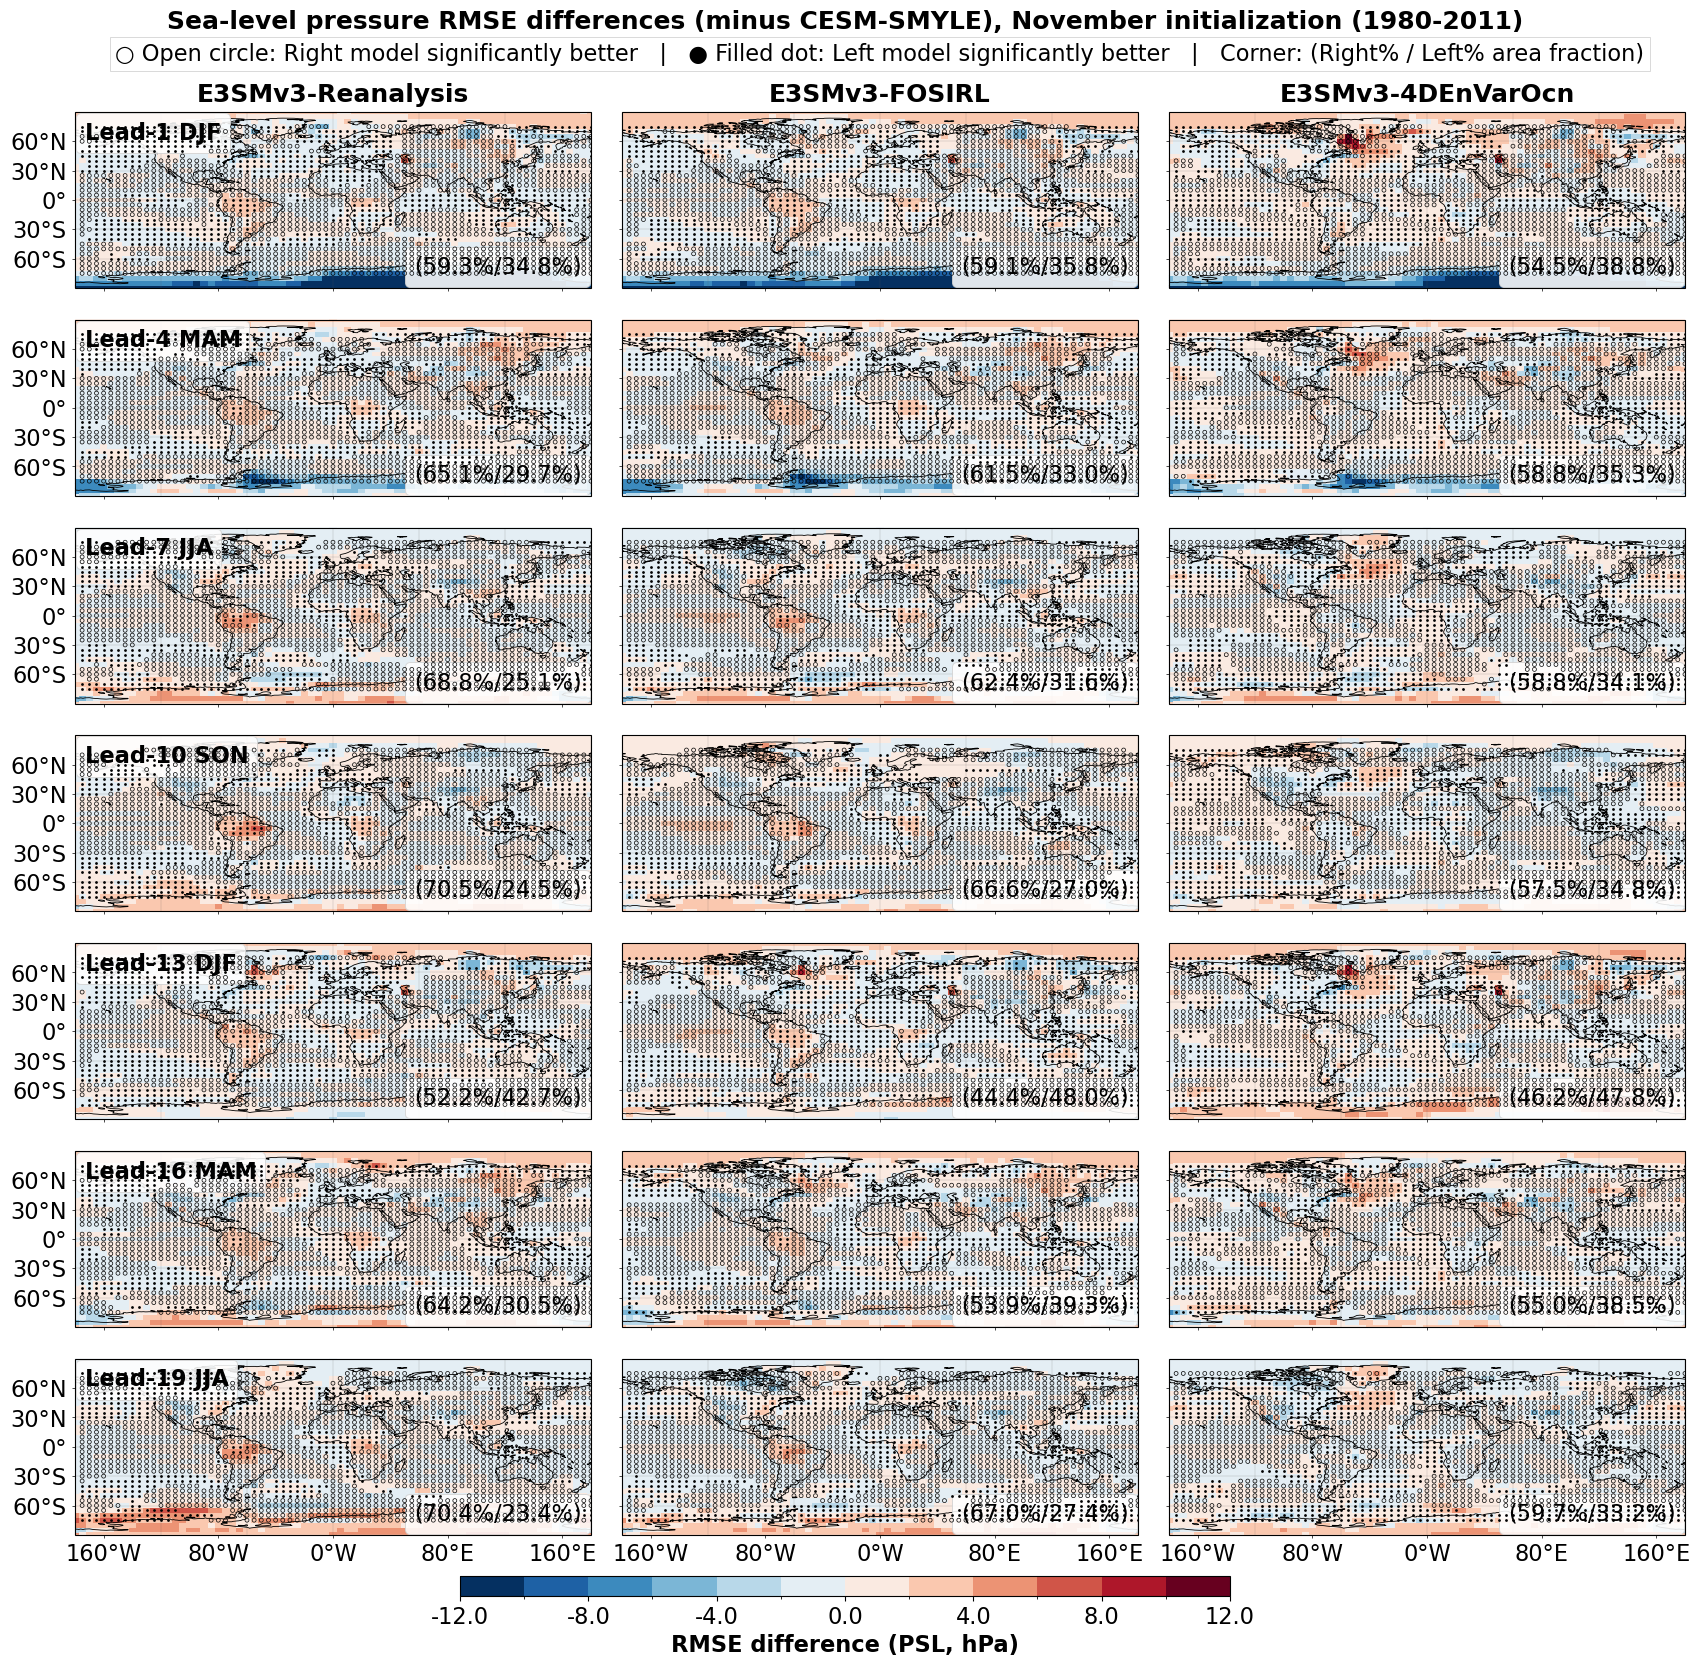

CPU times: user 14.6 s, sys: 1.5 s, total: 16.1 s
Wall time: 15.5 s


In [104]:
%%time
comparison_label = {
    "CESM-SMYLE": "CESM-SMYLE",
    **{case_key: case_info["display_name"] for case_key, case_info in E3SM_CASE_CATALOG.items()},
}
comparison_specs = [
    {
        "key": f"{left_model}_minus_{right_model}",
        "left_model": left_model,
        "right_model": right_model,
        "left_label": comparison_label.get(left_model, left_model),
        "right_label": comparison_label.get(right_model, right_model),
    }
    for left_model, right_model in REQUESTED_DIFFERENCE_COMPARISONS
    if right_model == reference_model
]
available_comparison_models = (
    ({"CESM-SMYLE"} if cfg.get("has_smyle_benchmark", True) else set()) | set(E3SM_CASES)
)
skipped_comparison_specs = [
    spec for spec in comparison_specs
    if spec["left_model"] not in available_comparison_models
    or spec["right_model"] not in available_comparison_models
]
comparison_specs = [
    spec for spec in comparison_specs if spec not in skipped_comparison_specs
]
for spec in skipped_comparison_specs:
    print(
        "Skipping disabled comparison:",
        f"{spec['left_model']} minus {spec['right_model']}",
    )
if not comparison_specs:
    raise ValueError("No requested comparison uses the enabled model set.")

required_models = sorted(
    {spec["left_model"] for spec in comparison_specs}
    | {spec["right_model"] for spec in comparison_specs}
)

if "direct_rmse_by_requested_model_month" not in globals():
    direct_rmse_by_requested_model_month = {model: {} for model in required_models}
else:
    for model in required_models:
        direct_rmse_by_requested_model_month.setdefault(model, {})

for model in required_models:
    for init_month in init_months:
        if init_month in direct_rmse_by_requested_model_month[model]:
            continue

        ds_rmse = None
        if model == "CESM-SMYLE" and "direct_rmse_smyle_by_month" in globals():
            ds_rmse = direct_rmse_smyle_by_month.get(init_month)
        elif "direct_rmse_e3sm_by_case_month" in globals():
            ds_rmse = direct_rmse_e3sm_by_case_month.get(model, {}).get(init_month)

        if ds_rmse is None:
            fpath = direct_rmse_filename(model, init_month)
            if not os.path.exists(fpath):
                print("Direct RMSE file not found:", fpath)
                continue
            ds_rmse = normalize_direct_rmse_leads(xr.open_dataset(fpath).load())
            print("Loaded direct RMSE file:", fpath)

        direct_rmse_by_requested_model_month[model][init_month] = (
            normalize_direct_rmse_leads(ds_rmse)
        )

requested_rmse_diff_by_column_month = {
    spec["key"]: {}
    for spec in comparison_specs
}

for spec in comparison_specs:
    for init_month in init_months:
        left_available = init_month in direct_rmse_by_requested_model_month[spec["left_model"]]
        right_available = init_month in direct_rmse_by_requested_model_month[spec["right_model"]]
        if not (left_available and right_available):
            continue
        requested_rmse_diff_by_column_month[spec["key"]][init_month] = (
            rmse_compare_helper.direct_rmse_difference(
                direct_rmse_by_requested_model_month[spec["left_model"]][init_month],
                direct_rmse_by_requested_model_month[spec["right_model"]][init_month],
            )
        )

matched_bootstrap_by_column_month = {
    spec["key"]: {} for spec in comparison_specs
}

for spec in comparison_specs:
    safe_left = safe_model_name(spec["left_model"])
    safe_right = safe_model_name(spec["right_model"])
    boot_output_dir = BOOT_RMSE_OUTDIRS[spec["left_model"]]
    for init_month in init_months:
        year_tag = compact_year_tag(SMYLE_MATCHED_YEARS_BY_MONTH[init_month])
        boot_path = os.path.join(
            boot_output_dir,
            f"{safe_left}_minus_{safe_right}_{field}_finite_ensemble_resampling_"
            f"init{init_month:02d}_years_{year_tag}_niter{NBOOT}.nc",
        )
        if os.path.exists(boot_path):
            matched_bootstrap_by_column_month[spec["key"]][init_month] = (
                normalize_direct_rmse_leads(xr.open_dataset(boot_path).load())
            )
        elif PLOT_MATCHED_ENSEMBLE_MARKERS:
            print("Matched-ensemble bootstrap file not found:", boot_path)

plot_months = [
    init_month for init_month in init_months
    if all(
        init_month in requested_rmse_diff_by_column_month[spec["key"]]
        for spec in comparison_specs
    )
]

if len(plot_months) == 0:
    raise ValueError("No initialization months available for plotting.")

norm = BoundaryNorm(clevs, ncolors=plt.get_cmap("RdBu_r").N, clip=True)
eval_years_label = f"{min(years)}-{max(years)}" if isinstance(years, (list, tuple, np.ndarray)) else f"{years}-{yeare}"

# Generate separate figures for each initialization month
for init_month in plot_months:
    plot_leads = [
        lead for lead in map_plot_leads
        if all(
            lead in requested_rmse_diff_by_column_month[spec["key"]][init_month].L.values
            for spec in comparison_specs
            if init_month in requested_rmse_diff_by_column_month[spec["key"]]
        )
    ]
    if len(plot_leads) == 0:
        print(f"Skipping init_month {init_month}: No leads available for plotting.")
        continue

    nrows = len(plot_leads)
    ncols = len(comparison_specs)
    fig_height = max(16.0, 2.35 * nrows)

    fig = plt.figure(figsize=(fig_width, fig_height))
    init_label = init_month_names.get(init_month, f"{init_month:02d}")
    subtitle = f"{cfg['plot_name']} RMSE differences (minus {reference_model}), {init_label} initialization ({eval_years_label})"
    fig.suptitle(subtitle, fontsize=compare_suptitle_size, fontweight=compare_fweight, y=compare_suptitle_y)

    fig.text(
        legend_x, legend_y,
        "○ Open circle: Right model significantly better   |   ● Filled dot: Left model significantly better   |   Corner: (Right% / Left% area fraction)",
        ha="center", va="center", fontsize=compare_legend_font_size, fontweight="medium",
        bbox=legend_bbox
    )

    gs = fig.add_gridspec(
        nrows=nrows, ncols=ncols,
        top=gs_top, bottom=gs_bottom, left=gs_left, right=gs_right,
        hspace=gs_hspace, wspace=gs_wspace,
    )

    cntr = None
    for i, lead in enumerate(plot_leads):
        for c_idx, spec in enumerate(comparison_specs):
            ax = fig.add_subplot(gs[i, c_idx], projection=ccrs.PlateCarree())
            ax.set_aspect("auto")

            if i == 0:
                # The figure title states the common reference_model baseline.
                # Retain both names only for comparisons with a different baseline.
                if spec['right_model'] == reference_model:
                    col_title = spec['left_label']
                else:
                    col_title = f"{spec['left_label']}\n− {spec['right_label']}"
                ax.set_title(col_title, fontsize=compare_panel_title_size, fontweight=compare_fweight, pad=7, linespacing=0.95)

            ds_diff = requested_rmse_diff_by_column_month[spec["key"]][init_month]
            da_diff = ds_diff["rmse_diff"].sel(L=lead)
            valid = da_diff.notnull()

            dat_cyc, lon_cyc = add_cyclic_point(da_diff.values, coord=da_diff.lon.values)
            cntr = ax.pcolormesh(
                lon_cyc, da_diff.lat.values, dat_cyc,
                shading="nearest", cmap="RdBu_r", norm=norm,
                rasterized=True, transform=ccrs.PlateCarree(),
            )
            ax.add_feature(cfeature.COASTLINE, linewidth=coastline_linewidth)

            # Significance markers
            boot_ds = matched_bootstrap_by_column_month[spec["key"]].get(init_month)
            if PLOT_MATCHED_ENSEMBLE_MARKERS and boot_ds is not None and lead in boot_ds.L.values:
                prob_left_better = boot_ds["prob_left_lower_rmse"].sel(L=lead)
                valid_prob = prob_left_better.notnull()
                left_better = (prob_left_better >= COMPARE_PROBABILITY_THRESHOLD).where(valid_prob)
                right_better = (prob_left_better <= (1 - COMPARE_PROBABILITY_THRESHOLD)).where(valid_prob)

                lon2d, lat2d = np.meshgrid(da_diff.lon, da_diff.lat)
                disp_lon = lon2d[::compare_marker_stride, ::compare_marker_stride]
                disp_lat = lat2d[::compare_marker_stride, ::compare_marker_stride]

                right_display = np.asarray(right_better.fillna(False), dtype=bool)[::compare_marker_stride, ::compare_marker_stride]
                left_display = np.asarray(left_better.fillna(False), dtype=bool)[::compare_marker_stride, ::compare_marker_stride]
                disp_mask_r = right_display & (abs(disp_lat) < latlim)
                disp_mask_l = left_display & (abs(disp_lat) < latlim)

                ax.scatter(disp_lon[disp_mask_r], disp_lat[disp_mask_r],
                           facecolor="none", edgecolor=compare_marker_color,
                           s=compare_open_marker_size, linewidth=compare_marker_linewidth,
                           transform=ccrs.PlateCarree(), zorder=20)

                ax.scatter(disp_lon[disp_mask_l], disp_lat[disp_mask_l],
                           facecolor=compare_marker_color, edgecolor=compare_marker_color,
                           s=compare_filled_marker_size, linewidth=0,
                           transform=ccrs.PlateCarree(), zorder=20)

                valid_panel = valid_prob & valid
                right_frac = valid_area_weighted_fraction(right_better, valid=valid_panel, area=destgrid.area, latitude_limit=latlim)
                left_frac = valid_area_weighted_fraction(left_better, valid=valid_panel, area=destgrid.area, latitude_limit=latlim)
                score_text = f"({right_frac * 100:3.1f}%/{left_frac * 100:3.1f}%)"
                sb = AnchoredText(score_text, loc="lower right",
                                  prop=dict(size=compare_score_badge_size, weight="medium", family="sans-serif"),
                                  frameon=True, pad=badge_pad, borderpad=badge_borderpad)
                sb.patch.set(**badge_bbox)
                ax.add_artist(sb)

            # Axis tick hygiene: longitude ticks only on bottom row, latitude ticks only on leftmost column
            is_left = (c_idx == 0)
            is_bottom = (i == nrows - 1)
            ax.set_xticks(compare_lon_ticks, crs=ccrs.PlateCarree())
            ax.set_yticks(compare_lat_ticks, crs=ccrs.PlateCarree())
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=True))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
            ax.tick_params(
                labelsize=compare_lat_lon_label_size, length=lat_lon_tick_length, width=lat_lon_tick_width,
                top=False, right=False,
                labelleft=is_left, labelbottom=is_bottom,
            )
            ax.gridlines(crs=ccrs.PlateCarree(), linewidth=gridline_width, color=gridline_color, alpha=gridline_alpha, linestyle=gridline_style, draw_labels=False)

            # Lead badge in upper-left corner of first column (avoids lower-right score badge collision)
            if c_idx == 0:
                badge_text = f"Lead-{lead - 2} {seasonal_label(init_month, lead)}"
                b = AnchoredText(badge_text, loc="upper left",
                                 prop=dict(size=compare_lead_badge_size, weight="bold", family="sans-serif"),
                                 frameon=True, pad=badge_pad, borderpad=badge_borderpad)
                b.patch.set(**badge_bbox)
                ax.add_artist(b)

    # Centered horizontal colorbar at the bottom
    cbar_ax = fig.add_axes(compare_colorbar_axes)
    cbar = fig.colorbar(cntr, cax=cbar_ax, orientation=compare_colorbar_orientation)
    cbar.set_ticks(colorbar_ticks)
    cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(f"%.{colorbar_tick_decimals}f"))
    cbar.set_label(f"RMSE difference ({field}, {metric_units})", fontsize=compare_colorbar_label_size, fontweight=compare_fweight)
    cbar.ax.tick_params(labelsize=compare_colorbar_tick_size)

    figname = FIGURE_FILENAMES.get("difference_compare_by_init", {}).get(
        init_month,
        f"fig_rmse_compare_{field.lower()}_rmse_difference_compare_init{init_month:02d}.png",
    )
    figpath = FIGURE_OUTDIR / figname
    mov.save_figure(
        fig, figpath,
        mode="",
        metric="rmse_compare",
        title=f"RMSE Comparison: {field} ({init_label} init)",
        caption=f"Multi-column RMSE difference comparison across experiments ({init_label} initialization)",
        dpi=dpi,
    )
    print("Saved figure:", figpath)
    plt.show()
    plt.close(fig)

## Resource cleanup

Close tracked NetCDF datasets and Dask resources after all outputs are written.

In [105]:
for name in ('direct_rmse_by_model', 'bootstrap_rmse_diff_by_pair_month'):
    for value in globals().get(name, {}).values():
        values = value.values() if isinstance(value, dict) else (value,)
        for dataset in values:
            close = getattr(dataset, 'close', None)
            if close is not None:
                close()
close_notebook_resources(globals())
plt.close('all')
print('Closed direct-RMSE datasets, figures, and Dask resources.')


Closed direct-RMSE datasets, figures, and Dask resources.
